<a href="https://colab.research.google.com/github/gitbidec6/Machine-Learning-Works/blob/main/Geotech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the geotechnical data from the Excel file
file_path = '/content/Geotech.xlsx'
try:
    df = pd.read_excel(file_path)
    print("Data loaded successfully. Here's a preview of the first 5 rows:")
    print(df.head())
    print("\nAnd here's some information about the columns and data types:")
    df.info()
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it's uploaded correctly.")
except Exception as e:
    print(f"An error occurred while loading the data: {e}")


Data loaded successfully. Here's a preview of the first 5 rows:
              Location  Depth  Diameter  1st Layer  C1  Theta 1  2nd layer  \
0  Gwandu bridge kebbi      9     0.305          2   0       29          5   
1  Gwandu bridge kebbi      9     0.406          2   0       29          5   
2  Gwandu bridge kebbi      9     0.508          2   0       29          5   
3  Gwandu bridge kebbi      9     0.610          2   0       29          5   
4  Gwandu bridge kebbi     10     0.305          2   0       29          5   

   C2  Theta 2  3rd layer   C3  Theta 3  Qu1(KN)   FS  QuFS(KN)  
0   8        4           2   0       33    134.0  2.0     268.0  
1   8        4           2   0       33    235.0  2.0     470.0  
2   8        4           2   0       33    352.0  2.0     704.0  
3   8        4           2   0       33    467.0  2.0     934.0  
4   8        4           3   0       33    578.0  2.0    1156.0  

And here's some information about the columns and data types:
<class '

Exploratory Data Analysis

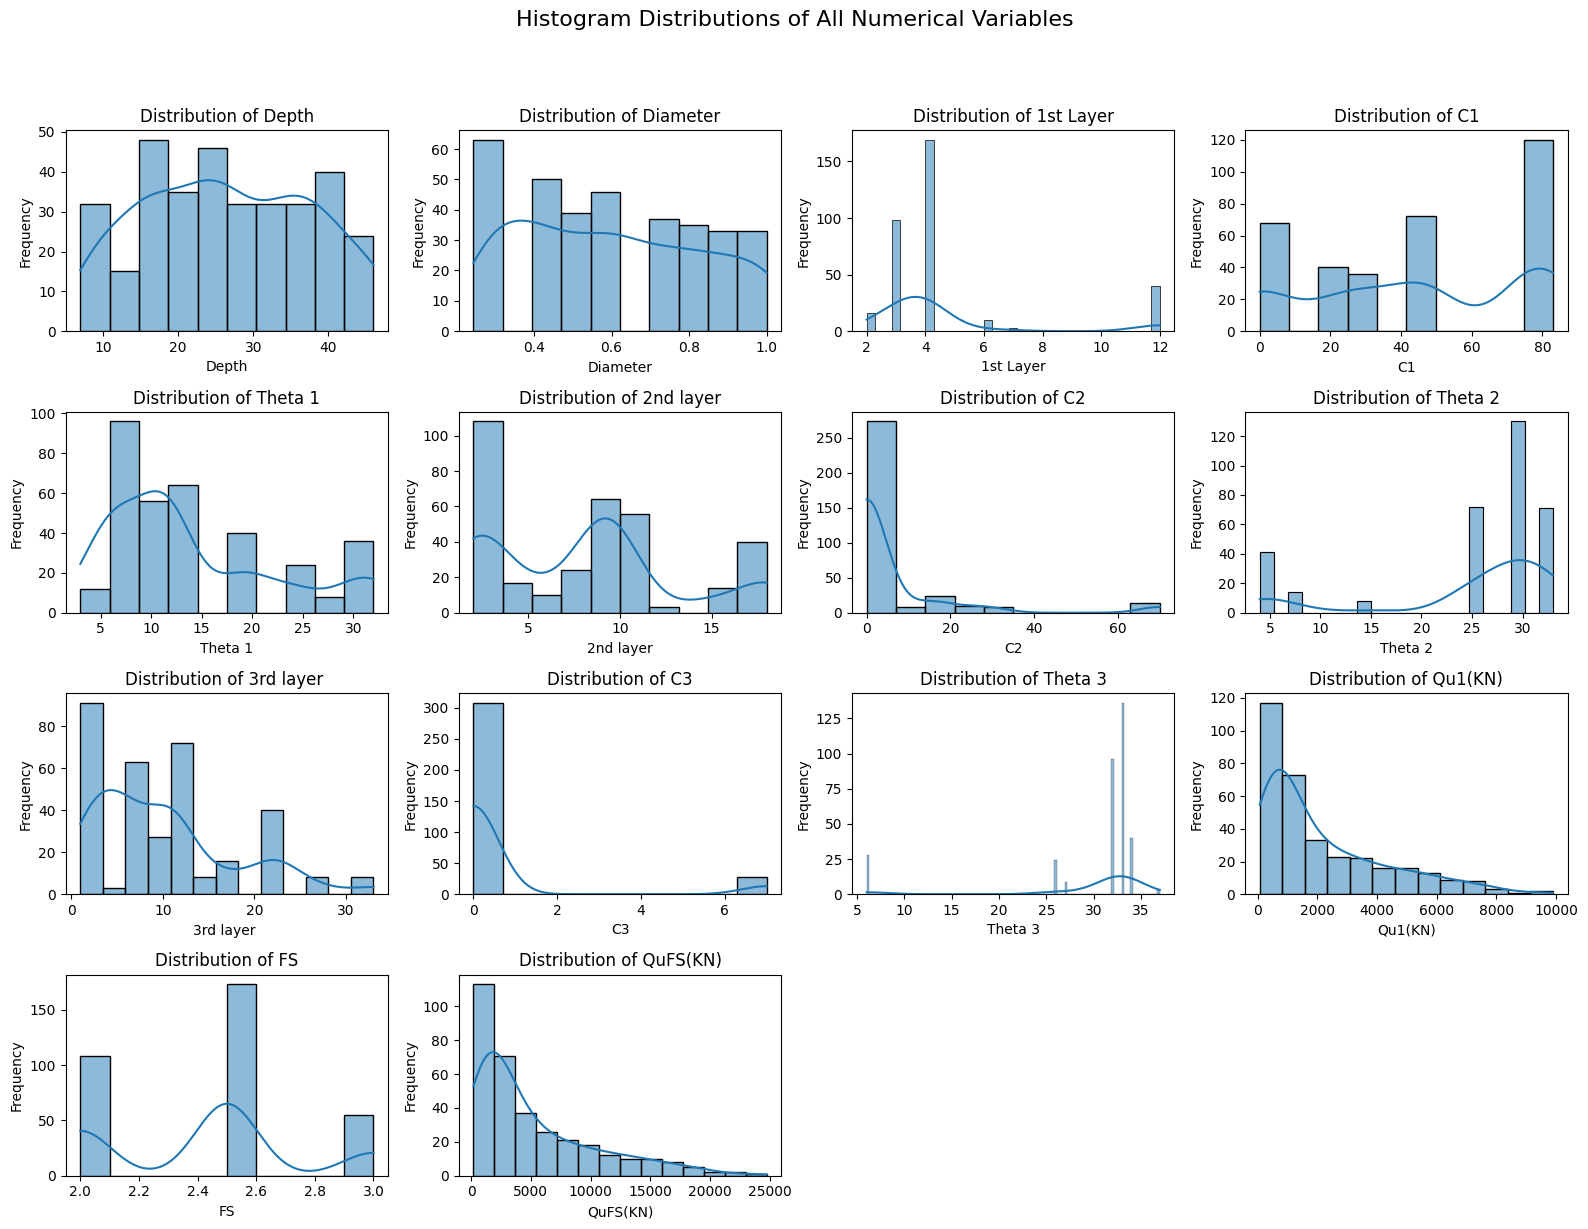

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Get numerical columns from df_cleaned (excluding 'Location' if it's still there after dropping)
numerical_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Calculate number of rows and columns for subplots
num_plots = len(numerical_cols)
num_cols_grid = 4  # You can adjust this for desired grid width
num_rows_grid = math.ceil(num_plots / num_cols_grid)

plt.figure(figsize=(num_cols_grid * 4, num_rows_grid * 3))
plt.suptitle('Histogram Distributions of All Numerical Variables', y=1.02, fontsize=16)

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows_grid, num_cols_grid, i + 1)
    sns.histplot(df_cleaned[col], kde=True) # kde=True adds a kernel density estimate
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

Generating a pairwise distribution plot. This may take a moment due to the number of variables.
Note: The 'Location' categorical feature is excluded from this pairplot for better readability,
as including it would make the plot very dense. This plot focuses on numerical relationships.


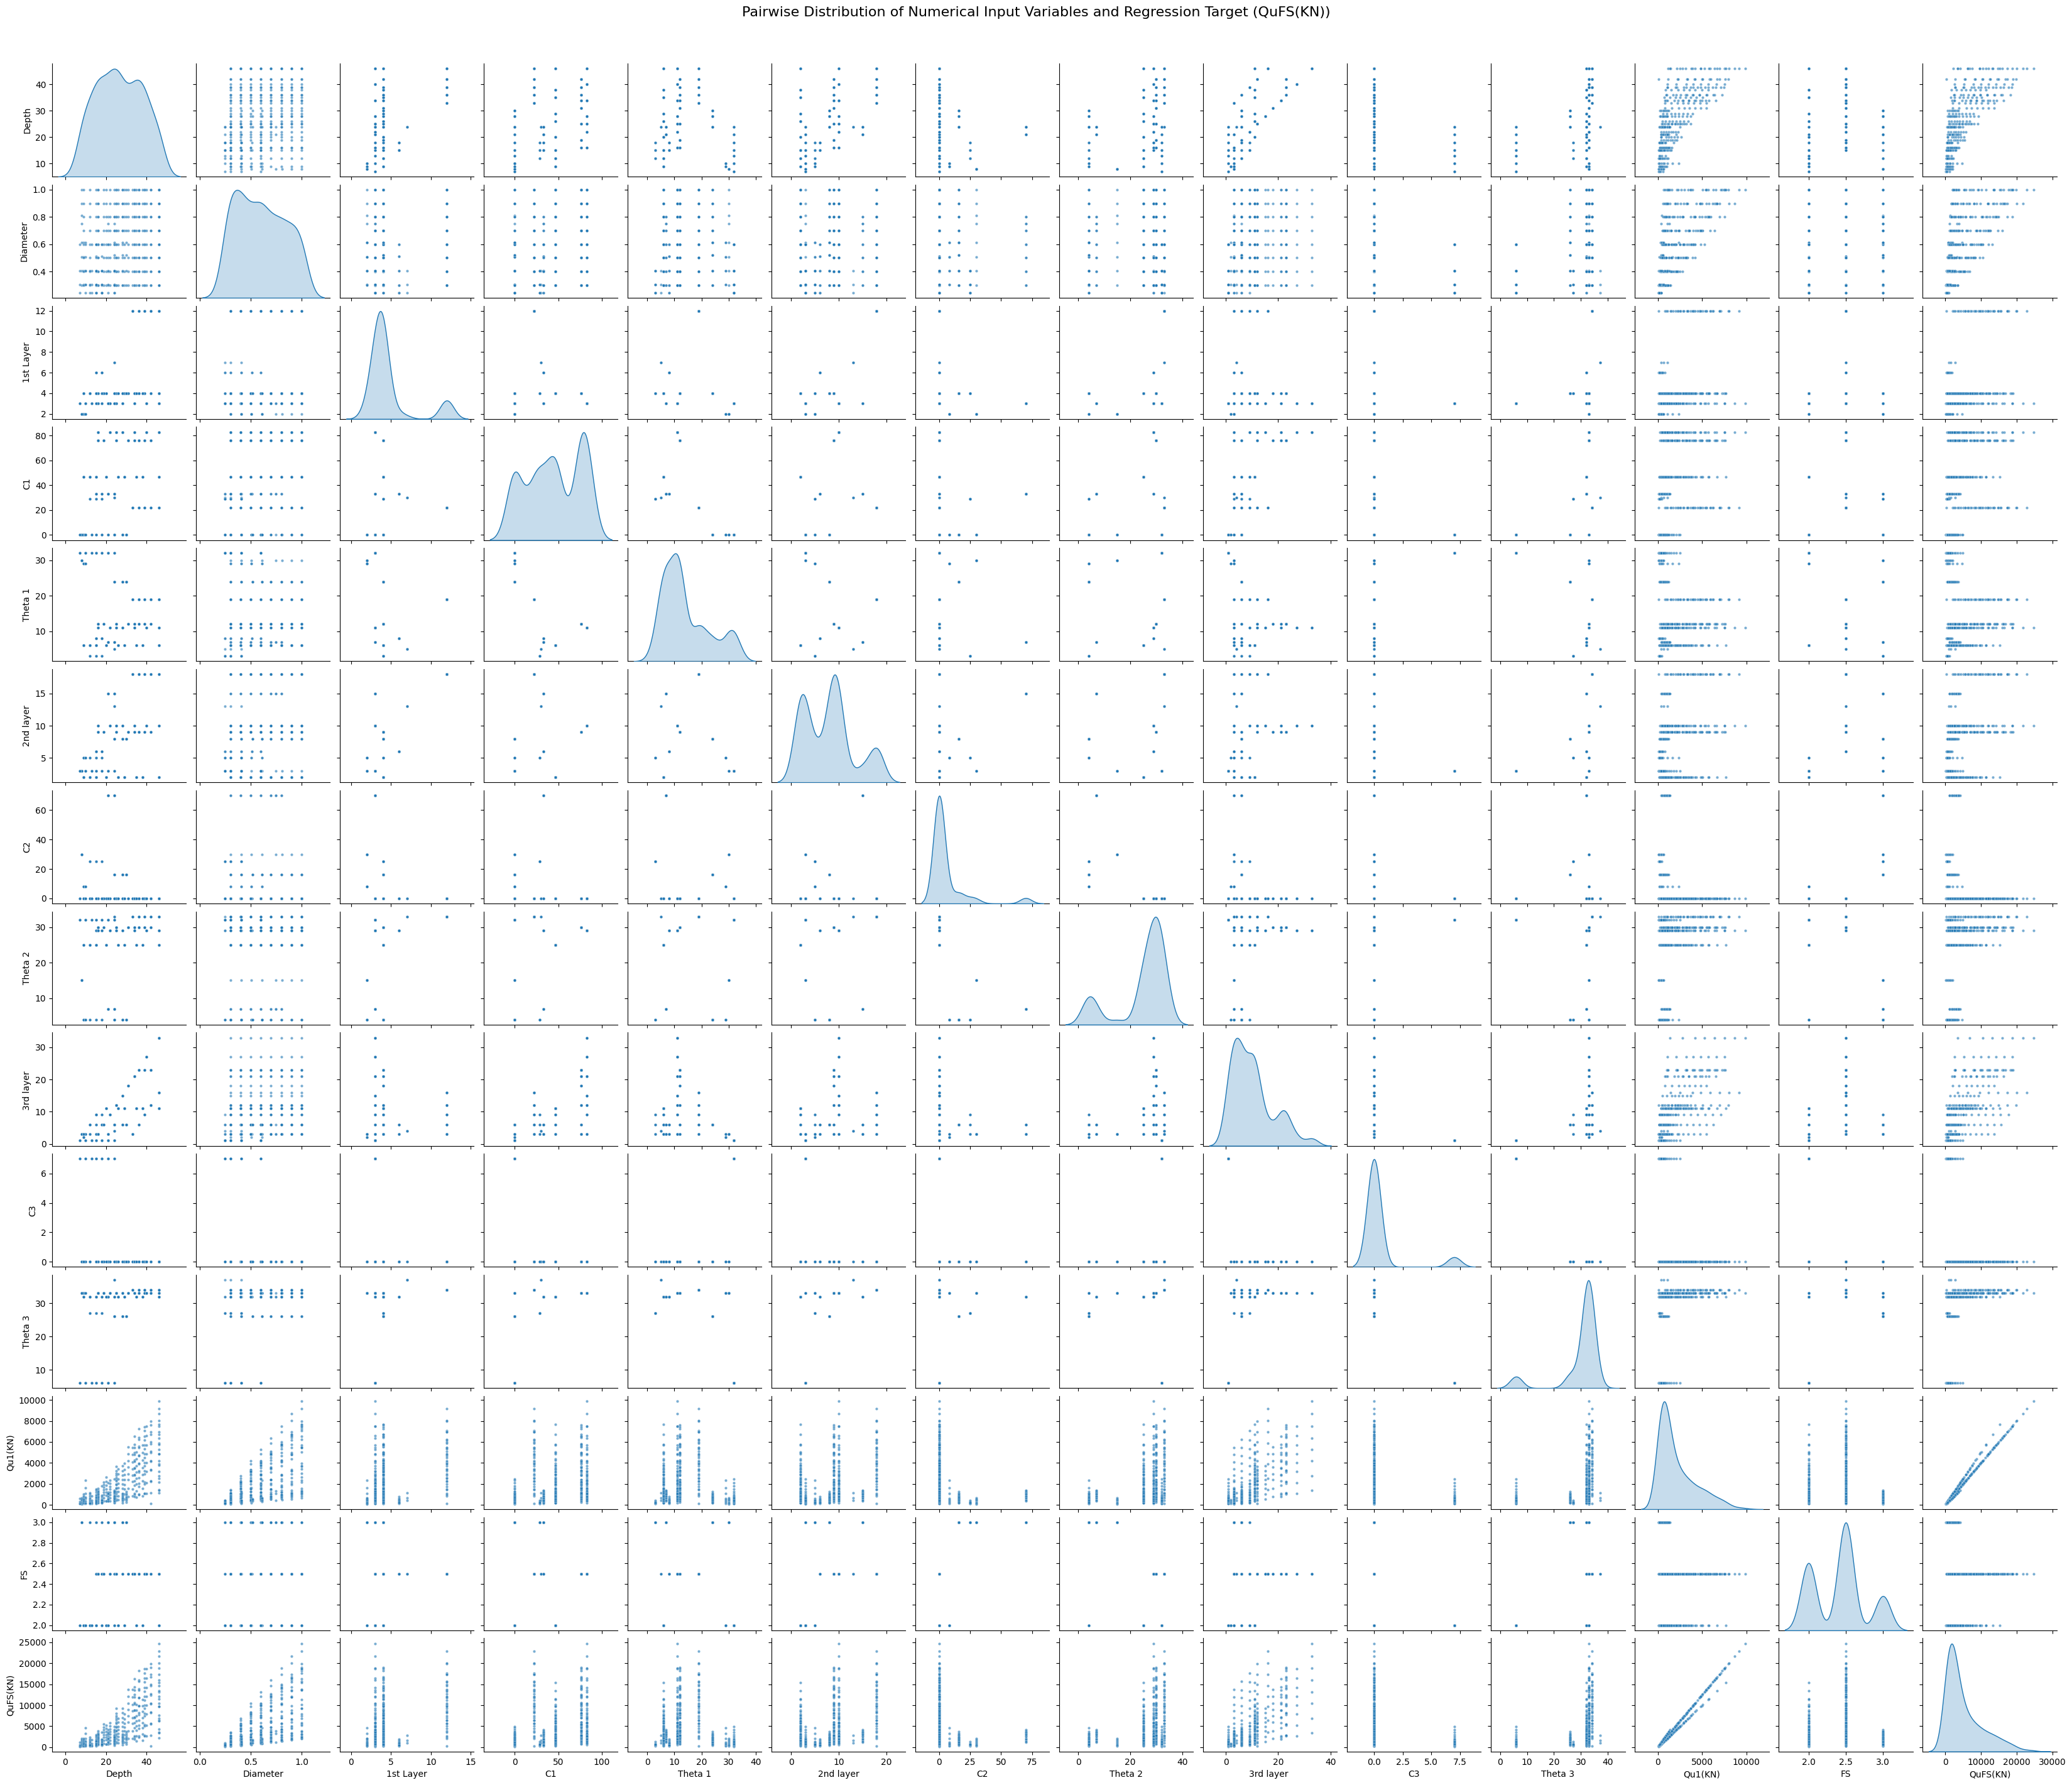

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# `numerical_features_regression` was defined earlier and contains all numerical input features
# `df_cleaned` is the preprocessed DataFrame with all original columns (except dropped NaN rows)
# `QuFS(KN)` is the regression target variable

# Create a DataFrame containing only the numerical input features and the regression target
# This ensures 'Location' (categorical input feature) is excluded for a cleaner numerical pairplot
plot_data = df_cleaned[numerical_features_regression + ['QuFS(KN)']]

print("Generating a pairwise distribution plot. This may take a moment due to the number of variables.")
print("Note: The 'Location' categorical feature is excluded from this pairplot for better readability,")
print("as including it would make the plot very dense. This plot focuses on numerical relationships.")

# Generate the pairplot with kernel density estimates on the diagonal
# Adjust height and aspect to make individual plots larger and more readable
g = sns.pairplot(plot_data, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 10}, height=2, aspect=1.2)
g.fig.suptitle('Pairwise Distribution of Numerical Input Variables and Regression Target (QuFS(KN))', y=1.02, fontsize=16) # Adjust title position
plt.show()

/tmp/ipykernel_4332/520595584.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=plot_df_numerical[col], ax=plt.gca(), palette='viridis')
/tmp/ipykernel_4332/520595584.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=plot_df_numerical[col], ax=plt.gca(), palette='viridis')
/tmp/ipykernel_4332/520595584.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=plot_df_numerical[col], ax=plt.gca(), palette='viridis')
/tmp/ipykernel_4332/520595584.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will

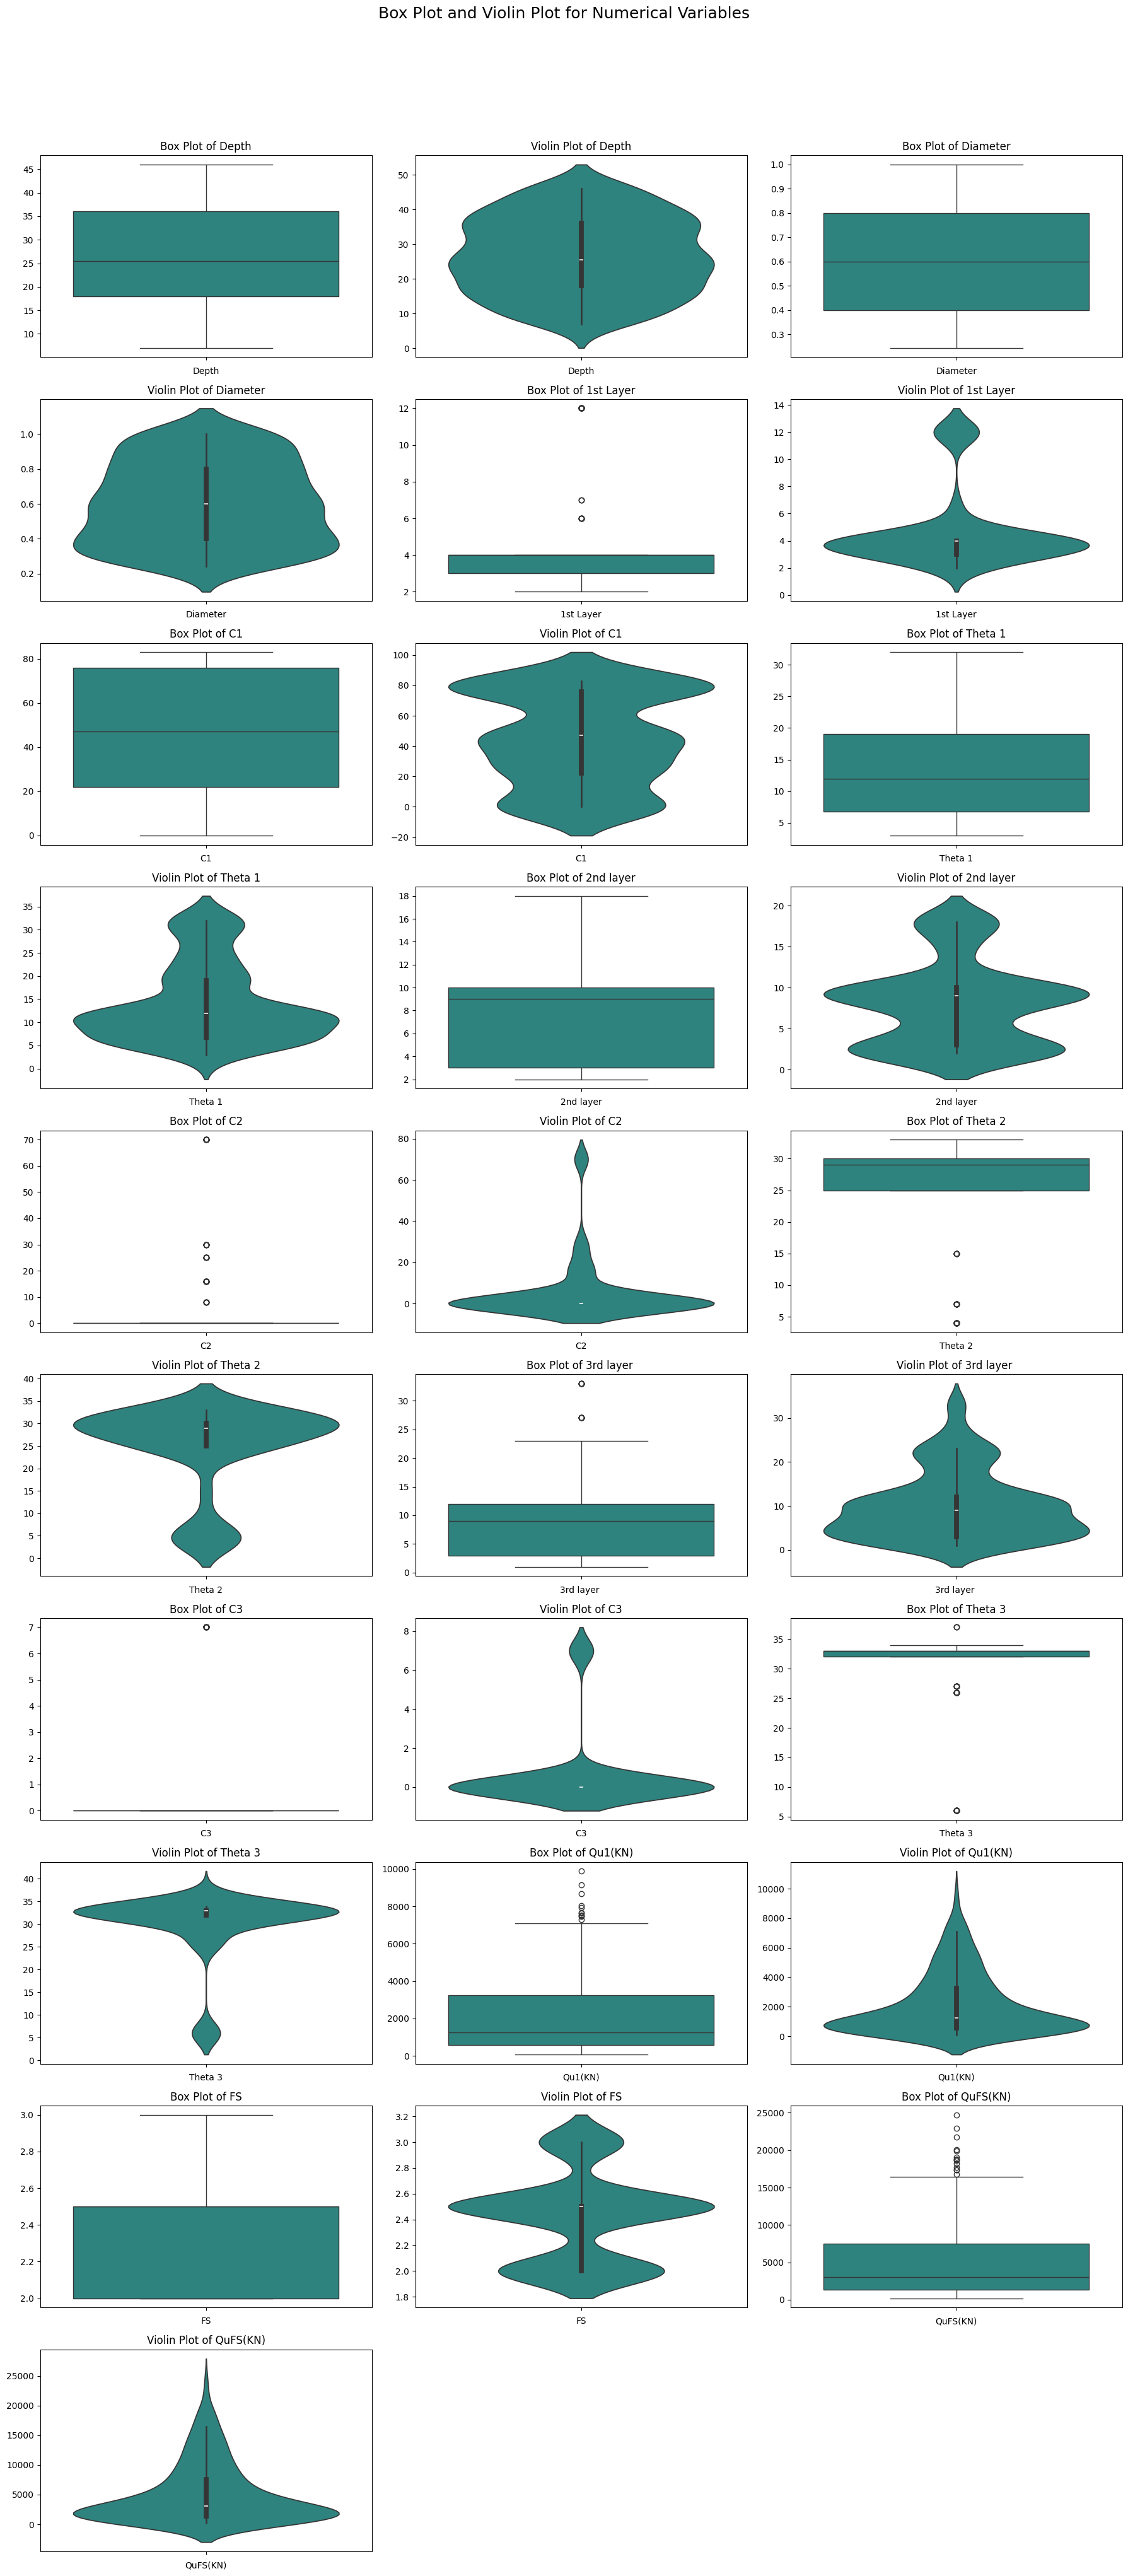

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Assuming df_cleaned is available and contains the preprocessed data
# and numerical_cols contains the list of numerical column names

# Filter df_cleaned to include only numerical columns for plotting
plot_df_numerical = df_cleaned[numerical_cols]

num_vars = len(plot_df_numerical.columns)
num_cols = 3 # Number of columns in the plot grid
num_rows = math.ceil(num_vars / num_cols)

plt.figure(figsize=(num_cols * 6, num_rows * 8))
plt.suptitle('Box Plot and Violin Plot for Numerical Variables', y=1.02, fontsize=18)

for i, col in enumerate(plot_df_numerical.columns):
    # Box Plot
    plt.subplot(num_rows * 2, num_cols, (i * 2) + 1)
    sns.boxplot(y=plot_df_numerical[col], ax=plt.gca(), palette='viridis')
    plt.title(f'Box Plot of {col}')
    plt.ylabel('') # Remove y-label to avoid clutter
    plt.xlabel(col)

    # Violin Plot
    plt.subplot(num_rows * 2, num_cols, (i * 2) + 2)
    sns.violinplot(y=plot_df_numerical[col], ax=plt.gca(), palette='viridis')
    plt.title(f'Violin Plot of {col}')
    plt.ylabel('') # Remove y-label to avoid clutter
    plt.xlabel(col)


plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

In [ ]:
# Drop rows where 'Location' is NaN, as it's the target for classification
df_cleaned = df.dropna(subset=['Location']).copy()

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after dropping rows with missing 'Location': {df_cleaned.shape}")

# Define features and targets for Classification
y_classification = df_cleaned['Location']
X_classification = df_cleaned.drop(columns=['Location'])

# Define features and targets for Regression (using QuFS(KN) based on earlier confirmation)
y_regression = df_cleaned['QuFS(KN)']
X_regression = df_cleaned.drop(columns=['QuFS(KN)'])

print("\nClassification Target unique values:")
print(y_classification.value_counts())

Original DataFrame shape: (337, 15)
DataFrame shape after dropping rows with missing 'Location': (336, 15)

Classification Target unique values:
Location
Iyora Anam spur bridge Anambra         72
Mmiata anam Anambra                    64
Mmiata Anam Bridge Anambra             56
Umunya Airport Anambra                 40
Okrika Water Front Rivers              28
Abalamabie, Bonny Island Rivers        24
Ukpor Bridge Anambra                   14
Nigerian Agip Isoko South              10
cellar slab ebocha oil field rivers     9
Gwandu bridge kebbi                     8
Gante Senatorial Kebbi                  8
Cellar pit Oleh Delta                   3
Name: count, dtype: int64


/tmp/ipykernel_4332/2874075026.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classification_target_counts.index, y=classification_target_counts.values, palette='viridis')


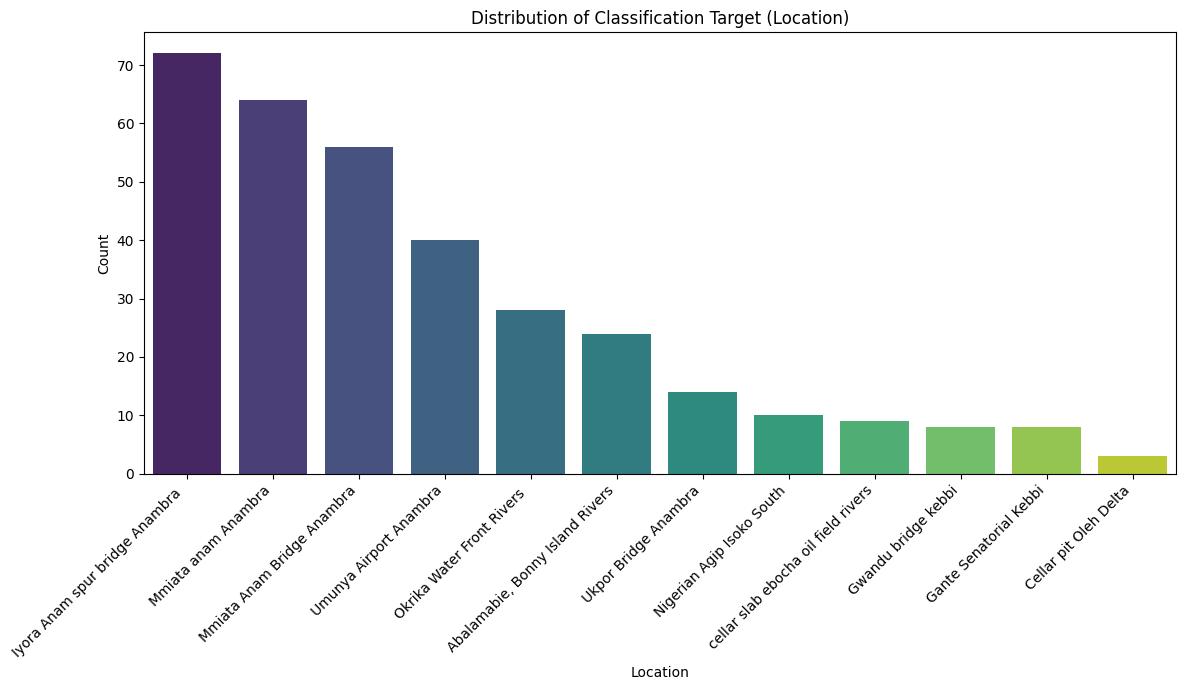

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the counts of unique values in the classification target
classification_target_counts = y_classification.value_counts()

plt.figure(figsize=(12, 7))
sns.barplot(x=classification_target_counts.index, y=classification_target_counts.values, palette='viridis')
plt.xlabel('Location')
plt.ylabel('Count')
plt.title('Distribution of Classification Target (Location)')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Saving all EDA plots to the 'EDA_Plots' directory...


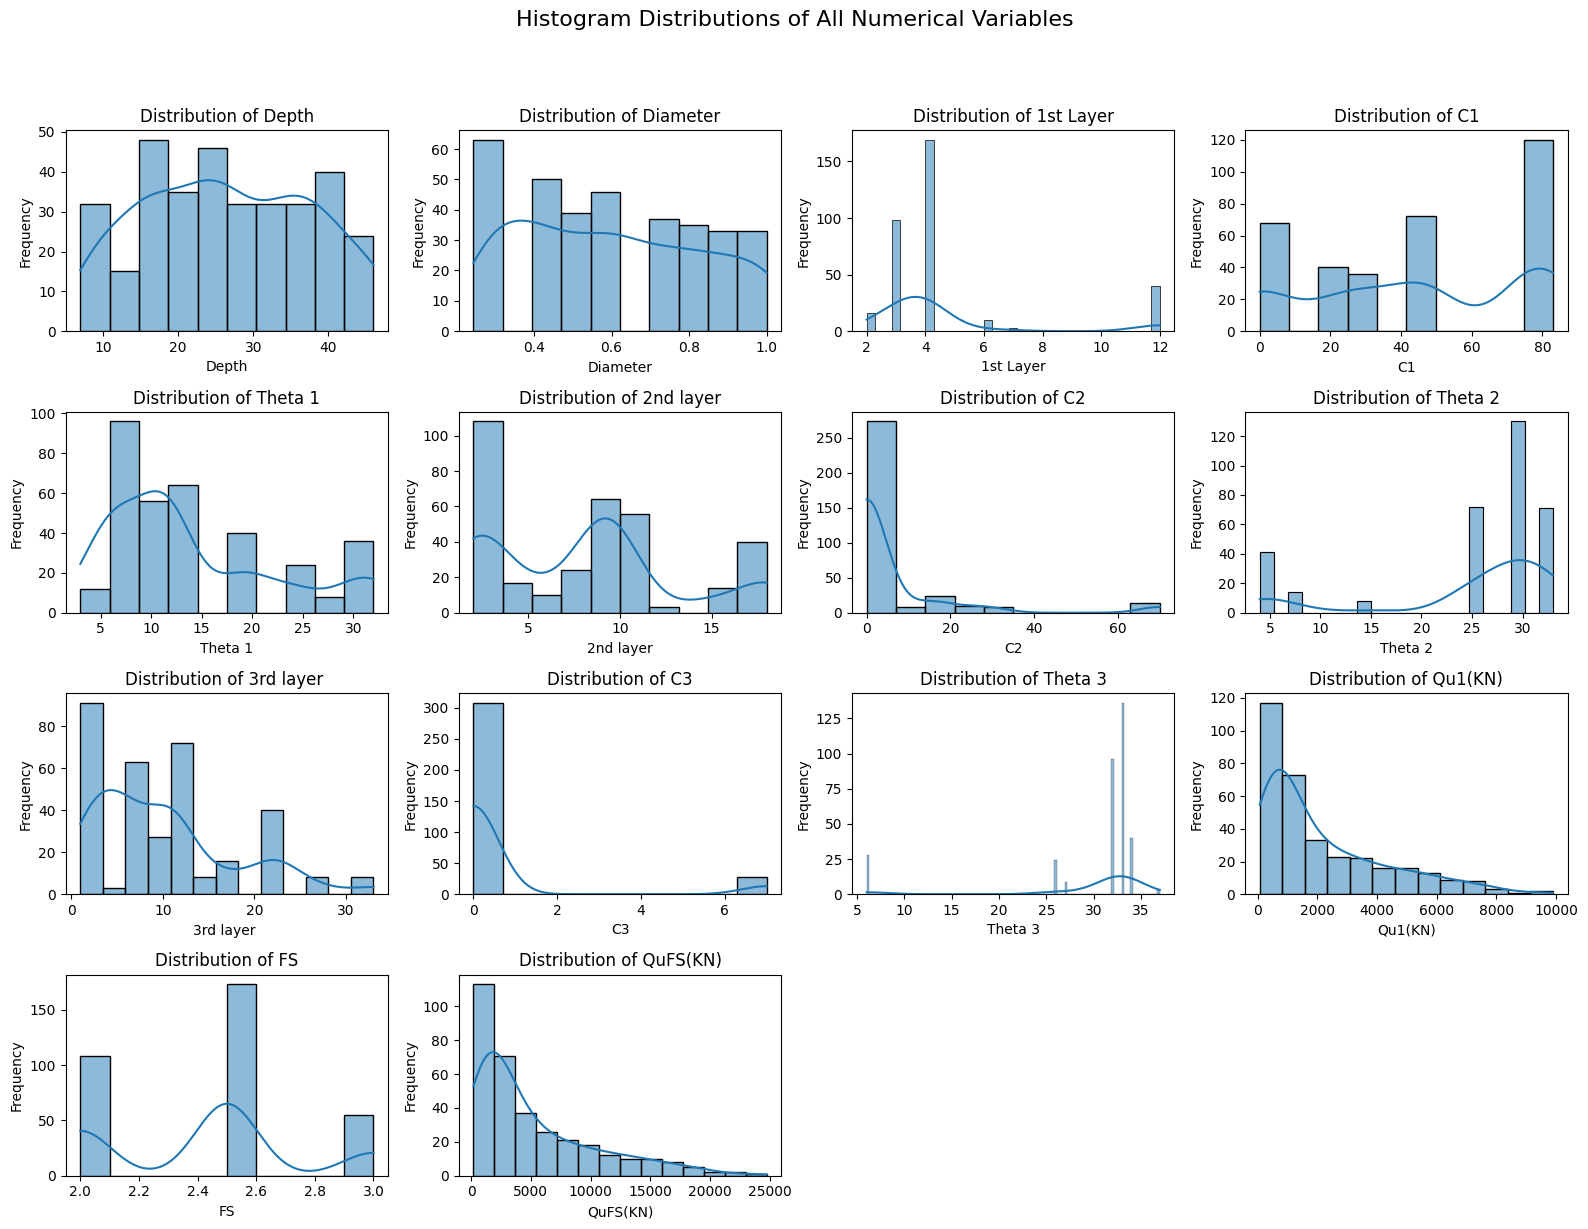

Histogram Distributions plot saved.


/tmp/ipykernel_4332/1798735341.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classification_target_counts.index, y=classification_target_counts.values, palette='viridis')


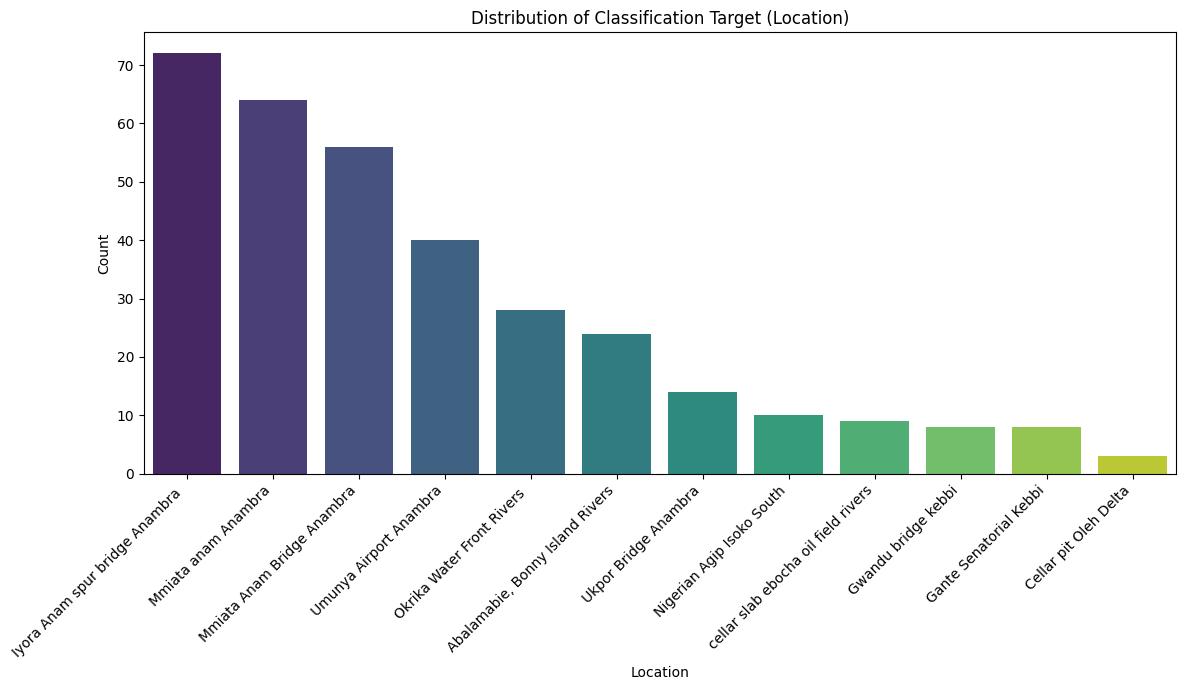

Classification Target Bar Chart saved.

Generating and saving pairwise distribution plot. This may take a moment.


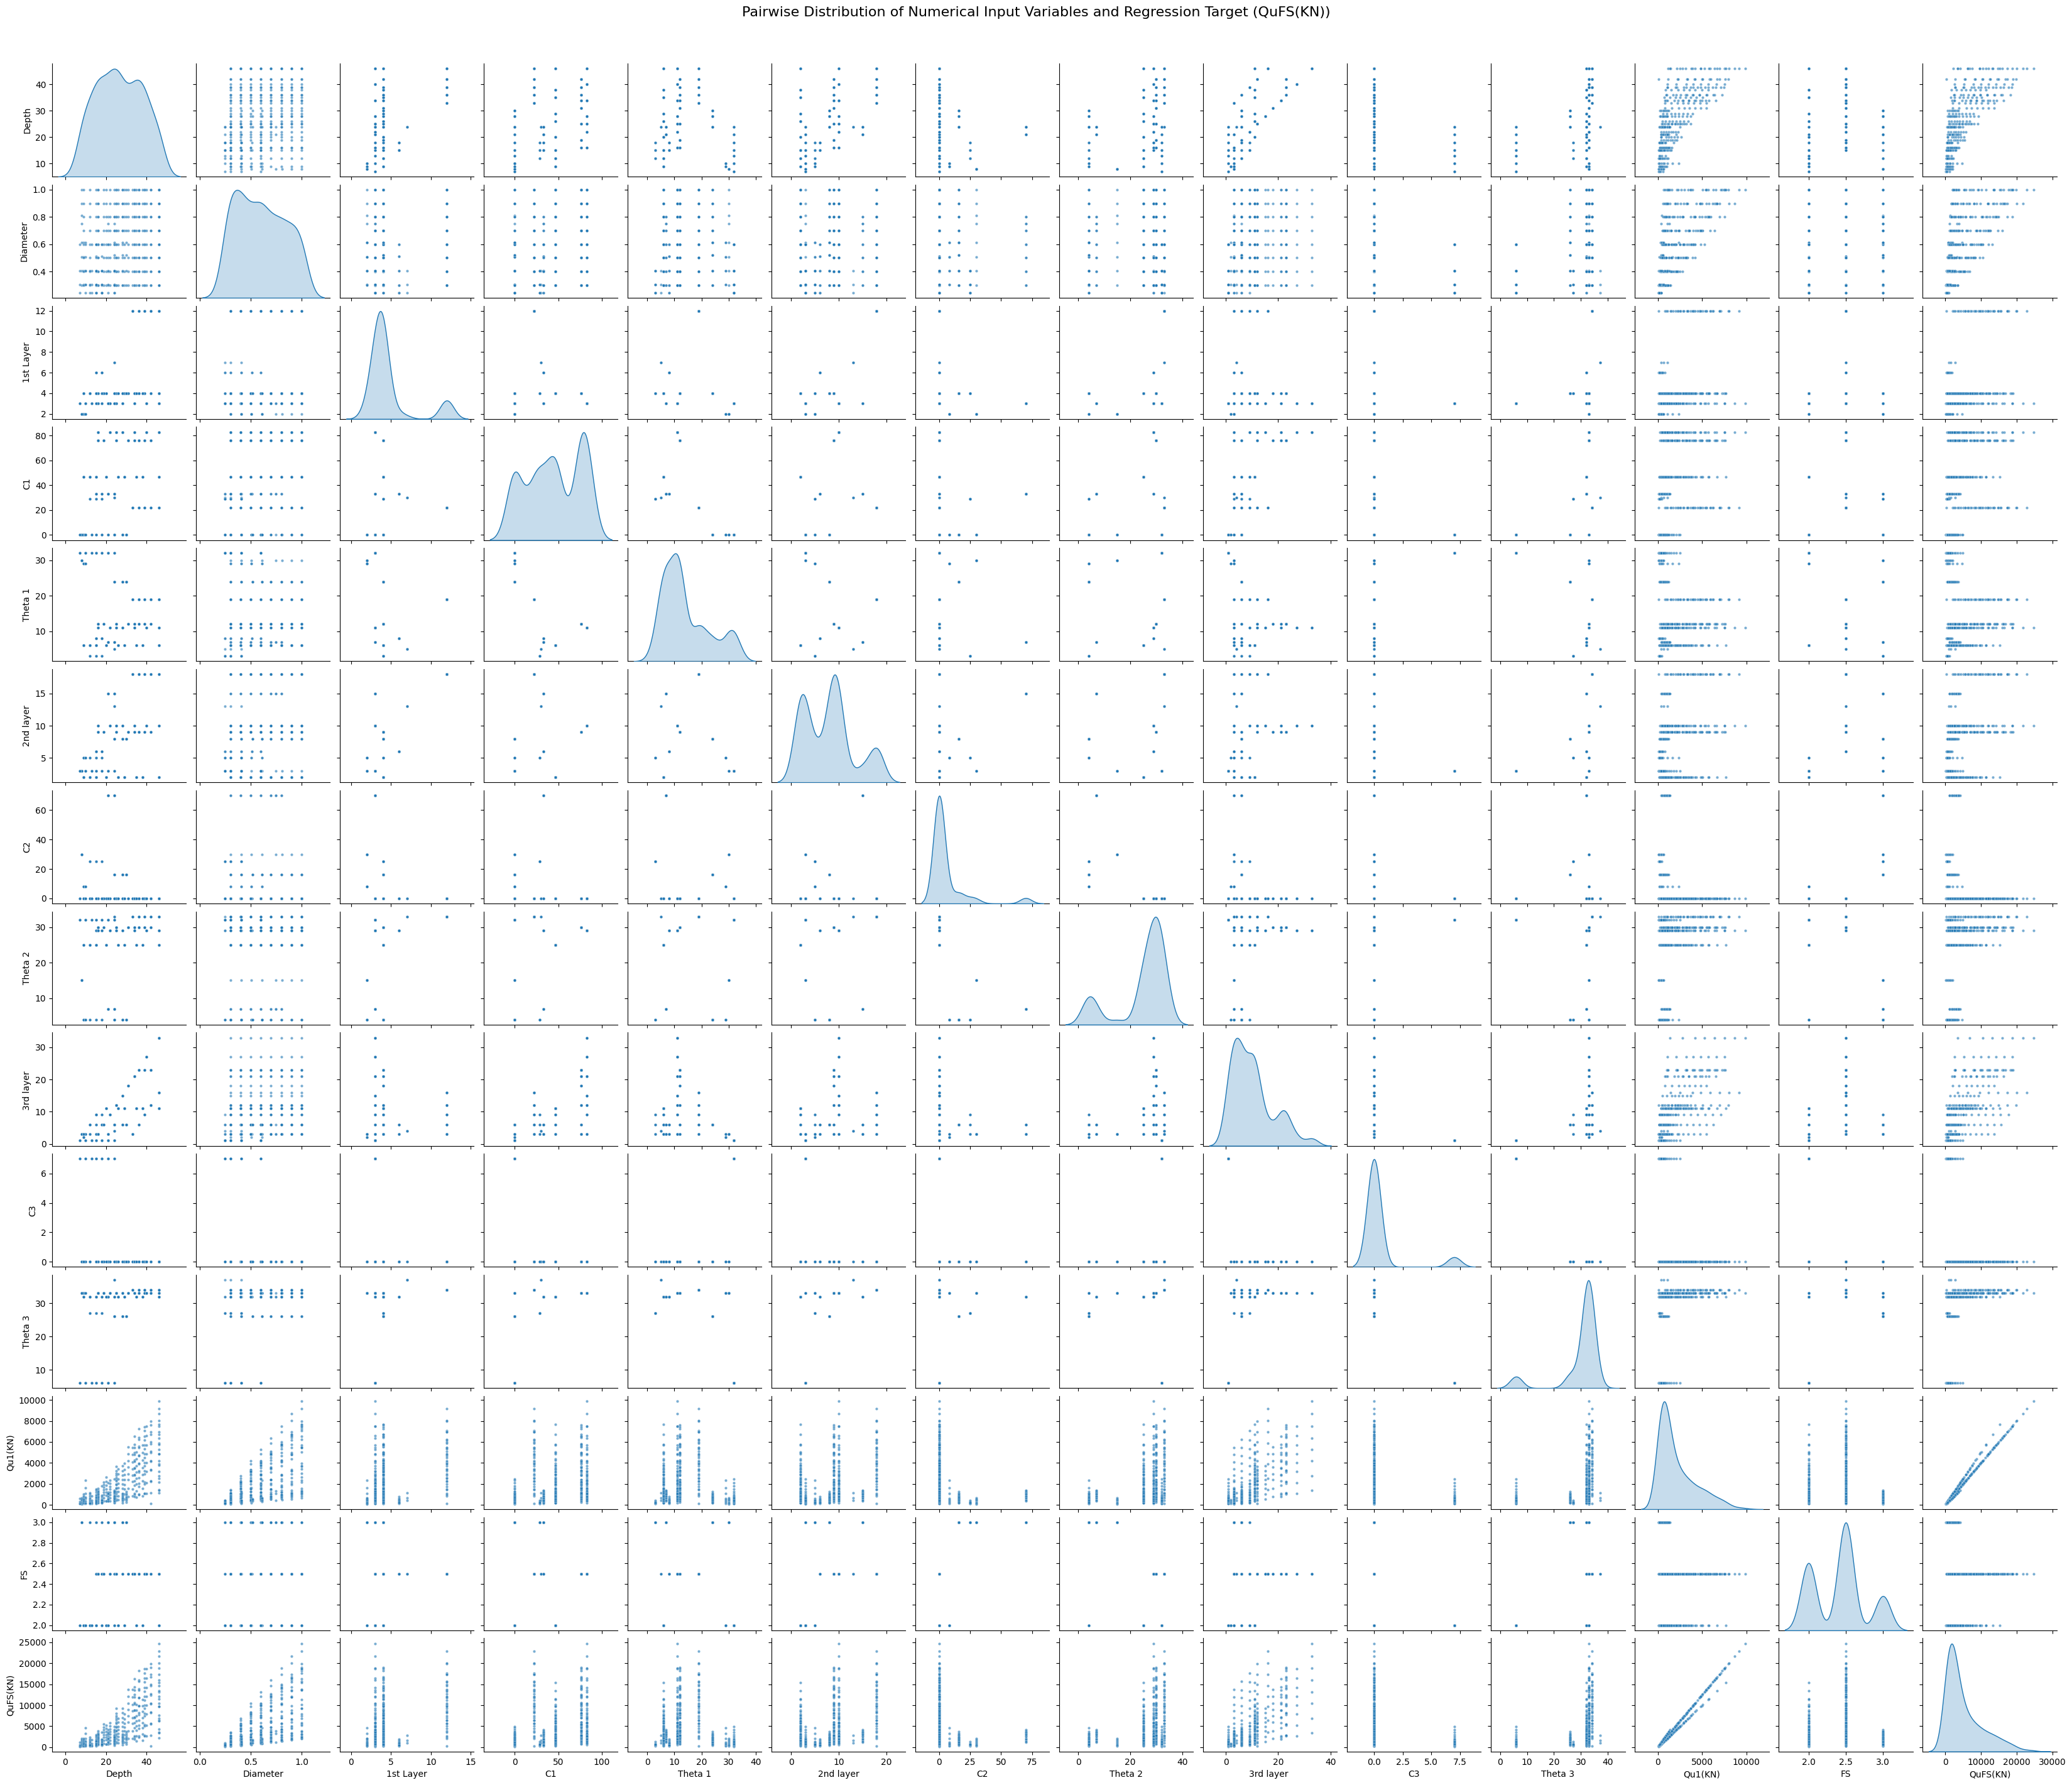

Pairwise Distribution plot saved.


/tmp/ipykernel_4332/1798735341.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=plot_df_numerical[col], ax=plt.gca(), palette='plasma')
/tmp/ipykernel_4332/1798735341.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=plot_df_numerical[col], ax=plt.gca(), palette='viridis')
/tmp/ipykernel_4332/1798735341.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=plot_df_numerical[col], ax=plt.gca(), palette='plasma')
/tmp/ipykernel_4332/1798735341.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wi

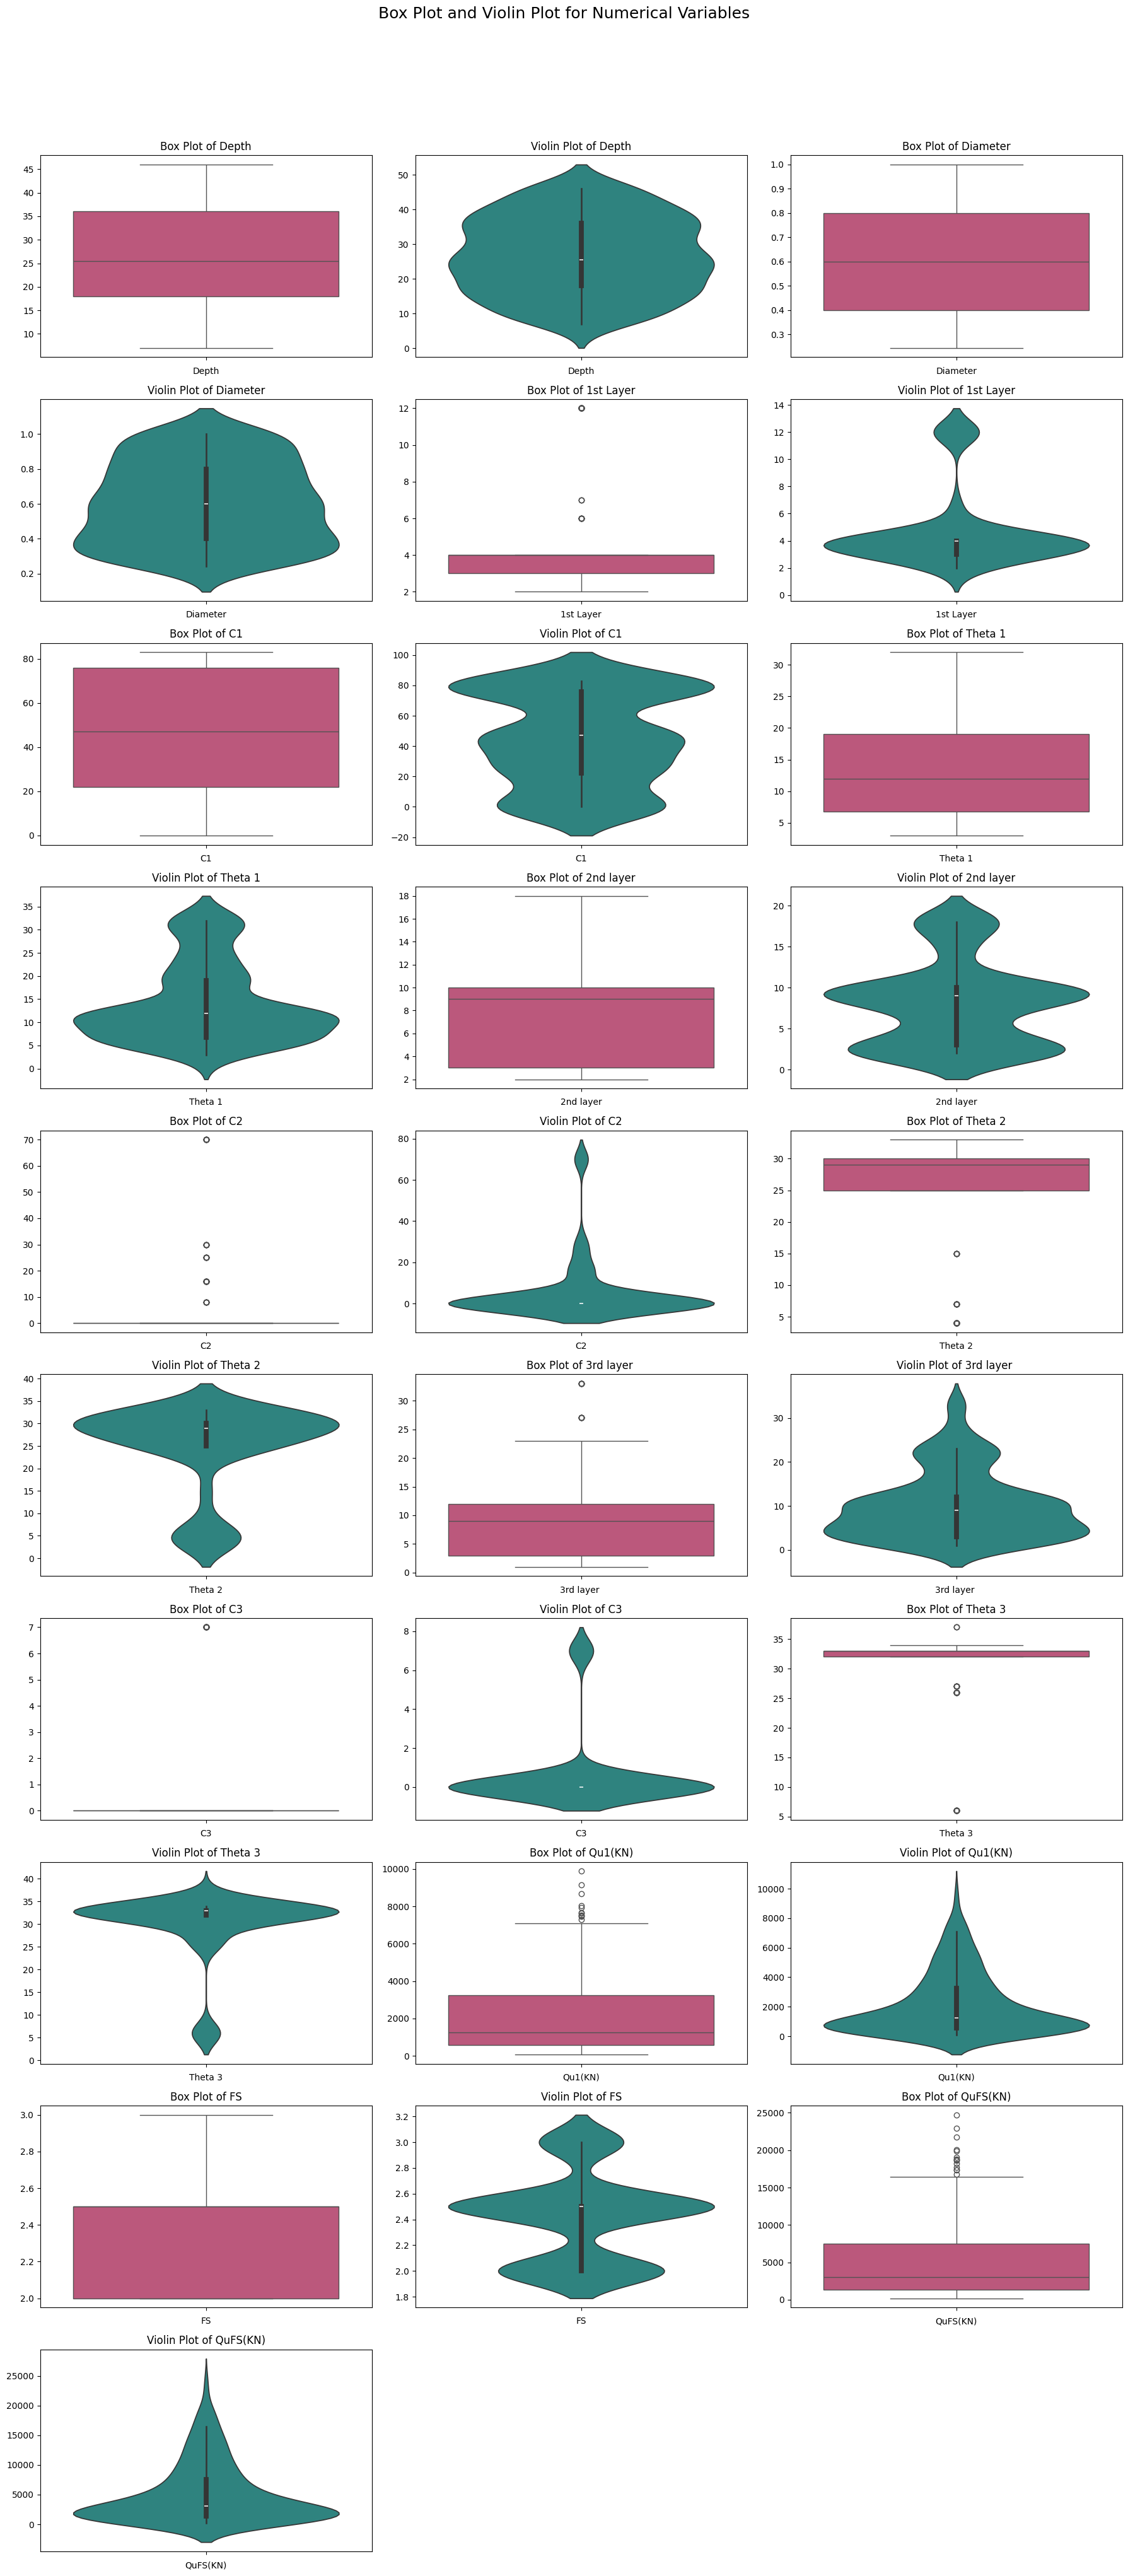

Box Plot and Violin Plot saved.

All EDA plots have been successfully saved to the 'EDA_Plots' directory.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
import pandas as pd

# Create a directory to save the plots if it doesn't exist
output_folder = 'EDA_Plots'
os.makedirs(output_folder, exist_ok=True)

print(f"Saving all EDA plots to the '{output_folder}' directory...")

# --- Plot 1: Histogram Distributions of All Numerical Variables ---
# Get numerical columns from df_cleaned (excluding 'Location' if it's still there after dropping)
numerical_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()

num_plots_hist = len(numerical_cols)
num_cols_grid_hist = 4 # You can adjust this for desired grid width
num_rows_grid_hist = math.ceil(num_plots_hist / num_cols_grid_hist)

plt.figure(figsize=(num_cols_grid_hist * 4, num_rows_grid_hist * 3))
plt.suptitle('Histogram Distributions of All Numerical Variables', y=1.02, fontsize=16)

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows_grid_hist, num_cols_grid_hist, i + 1)
    sns.histplot(df_cleaned[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(os.path.join(output_folder, 'histogram_distributions.png'))
plt.show()
print("Histogram Distributions plot saved.")

# --- Plot 2: Bar chart of Classification Target ---
classification_target_counts = y_classification.value_counts()

plt.figure(figsize=(12, 7))
sns.barplot(x=classification_target_counts.index, y=classification_target_counts.values, palette='viridis')
plt.xlabel('Location')
plt.ylabel('Count')
plt.title('Distribution of Classification Target (Location)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'classification_target_barchart.png'))
plt.show()
print("Classification Target Bar Chart saved.")

# --- Plot 3: Pairwise Distribution of Numerical Input Variables and Regression Target ---
# numerical_features_regression is available from previous execution
plot_data_pair = df_cleaned[numerical_features_regression + ['QuFS(KN)']]

print("\nGenerating and saving pairwise distribution plot. This may take a moment.")
g = sns.pairplot(plot_data_pair, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 10}, height=2, aspect=1.2)
g.fig.suptitle('Pairwise Distribution of Numerical Input Variables and Regression Target (QuFS(KN))', y=1.02, fontsize=16)
plt.savefig(os.path.join(output_folder, 'pairwise_distribution.png'))
plt.show()
print("Pairwise Distribution plot saved.")

# --- Plot 4: Box Plot and Violin Plot for Numerical Variables ---
plot_df_numerical = df_cleaned[numerical_cols]

num_vars_bv = len(plot_df_numerical.columns)
num_cols_bv = 3
num_rows_bv = math.ceil(num_vars_bv / num_cols_bv)

plt.figure(figsize=(num_cols_bv * 6, num_rows_bv * 8))
plt.suptitle('Box Plot and Violin Plot for Numerical Variables', y=1.02, fontsize=18)

for i, col in enumerate(plot_df_numerical.columns):
    # Box Plot
    plt.subplot(num_rows_bv * 2, num_cols_bv, (i * 2) + 1)
    sns.boxplot(y=plot_df_numerical[col], ax=plt.gca(), palette='plasma')
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
    plt.xlabel(col)

    # Violin Plot
    plt.subplot(num_rows_bv * 2, num_cols_bv, (i * 2) + 2)
    sns.violinplot(y=plot_df_numerical[col], ax=plt.gca(), palette='viridis')
    plt.title(f'Violin Plot of {col}')
    plt.ylabel('')
    plt.xlabel(col)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(os.path.join(output_folder, 'box_violin_plots.png'))
plt.show()
print("Box Plot and Violin Plot saved.")

print(f"\nAll EDA plots have been successfully saved to the '{output_folder}' directory.")

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Classification Preprocessing ---
# Encode the target variable 'Location'
le = LabelEncoder()
y_classification_encoded = le.fit_transform(y_classification)

# Identify numerical features for classification (all columns in X_classification are numerical after dropping 'Location')
numerical_features_classification = X_classification.columns.tolist()

# Create a preprocessor for classification features (only scaling numerical)
preprocessor_classification = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_classification)
    ])

# Apply preprocessing to X_classification
X_classification_processed = preprocessor_classification.fit_transform(X_classification)

print("Classification target (encoded):\n", y_classification_encoded[:5])
print("\nShape of processed X for classification:", X_classification_processed.shape)

# --- Regression Preprocessing ---
# Identify categorical and numerical features for regression
categorical_features_regression = ['Location'] # 'Location' is the only object type column in X_regression
numerical_features_regression = X_regression.drop(columns=['Location']).columns.tolist()

# Create a preprocessor for regression features (one-hot encode 'Location', scale numerical)
preprocessor_regression = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_regression),
        ('num', StandardScaler(), numerical_features_regression)
    ])

# Apply preprocessing to X_regression
X_regression_processed = preprocessor_regression.fit_transform(X_regression)

print("\nShape of processed X for regression:", X_regression_processed.shape)
print("\nRegression target (first 5 values):\n", y_regression.head())

Classification target (encoded):
 [3 3 3 3 3]

Shape of processed X for classification: (336, 14)

Shape of processed X for regression: (336, 25)

Regression target (first 5 values):
 0     268.0
1     470.0
2     704.0
3     934.0
4    1156.0
Name: QuFS(KN), dtype: float64


### Data Preprocessing

We will now prepare the data for both classification and regression tasks. This involves:
1.  Handling missing values.
2.  Separating features (X) and targets (y) for each task.
3.  Applying appropriate encoding for categorical features and targets, and scaling for numerical features.

### Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

# --- Classification Data Split ---
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_classification_processed, y_classification_encoded, test_size=0.2, random_state=42, stratify=y_classification_encoded
)
print(f"Classification training set shape (X, y): {X_train_cls.shape}, {y_train_cls.shape}")
print(f"Classification testing set shape (X, y): {X_test_cls.shape}, {y_test_cls.shape}")

# --- Regression Data Split ---
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression_processed, y_regression, test_size=0.2, random_state=42
)
print(f"Regression training set shape (X, y): {X_train_reg.shape}, {y_train_reg.shape}")
print(f"Regression testing set shape (X, y): {X_test_reg.shape}, {y_test_reg.shape}")


Classification training set shape (X, y): (268, 14), (268,)
Classification testing set shape (X, y): (68, 14), (68,)
Regression training set shape (X, y): (268, 25), (268,)
Regression testing set shape (X, y): (68, 25), (68,)


Classification Learner Algorithms

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Dictionary to store models and their performance
models = {
    "RandomForestClassifier": RandomForestClassifier(n_estimators=100, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "SVC": SVC(probability=True, random_state=42),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42)
}

performance_metrics = {}

# Get all possible class labels from the LabelEncoder
all_class_labels = np.arange(len(le.classes_))

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_cls, y_train_cls)
    y_pred = model.predict(X_test_cls)

    accuracy = accuracy_score(y_test_cls, y_pred)
    report = classification_report(y_test_cls, y_pred, target_names=le.classes_, labels=all_class_labels, zero_division=0, output_dict=True)

    performance_metrics[name] = {
        "accuracy": accuracy,
        "report": report
    }

    print(f"{name} Accuracy: {accuracy:.4f}")
    print(f"Classification Report for {name}:\n")
    print(classification_report(y_test_cls, y_pred, target_names=le.classes_, labels=all_class_labels, zero_division=0))


--- Training RandomForestClassifier ---
RandomForestClassifier Accuracy: 1.0000
Classification Report for RandomForestClassifier:

                                     precision    recall  f1-score   support

    Abalamabie, Bonny Island Rivers       1.00      1.00      1.00         5
              Cellar pit Oleh Delta       0.00      0.00      0.00         0
             Gante Senatorial Kebbi       1.00      1.00      1.00         2
                Gwandu bridge kebbi       1.00      1.00      1.00         2
    Iyora Anam spur bridge Anambra        1.00      1.00      1.00        14
         Mmiata Anam Bridge Anambra       1.00      1.00      1.00        11
                Mmiata anam Anambra       1.00      1.00      1.00        13
          Nigerian Agip Isoko South       1.00      1.00      1.00         2
         Okrika Water Front Rivers        1.00      1.00      1.00         6
               Ukpor Bridge Anambra       1.00      1.00      1.00         3
             Umunya 

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Weighted Avg Precision', 'Weighted Avg Recall', 'Weighted Avg F1-Score'])

for name, metrics in performance_metrics.items():
    accuracy = metrics['accuracy']
    report = metrics['report']

    weighted_avg_precision = report['weighted avg']['precision']
    weighted_avg_recall = report['weighted avg']['recall']
    weighted_avg_f1 = report['weighted avg']['f1-score']

    comparison_df.loc[len(comparison_df)] = [
        name, accuracy, weighted_avg_precision, weighted_avg_recall, weighted_avg_f1
    ]

comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("\n--- Classification Model Comparison ---")
display(comparison_df)


--- Classification Model Comparison ---


,Model,Accuracy,Weighted Avg Precision,Weighted Avg Recall,Weighted Avg F1-Score
0,RandomForestClassifier,1.000000,1.000000,1.000000,1.000000
1,LogisticRegression,1.000000,1.000000,1.000000,1.000000
2,GradientBoostingClassifier,1.000000,1.000000,1.000000,1.000000
3,SVC,0.941176,0.955017,0.941176,0.938562
4,KNeighborsClassifier,0.867647,0.883088,0.867647,0.850802


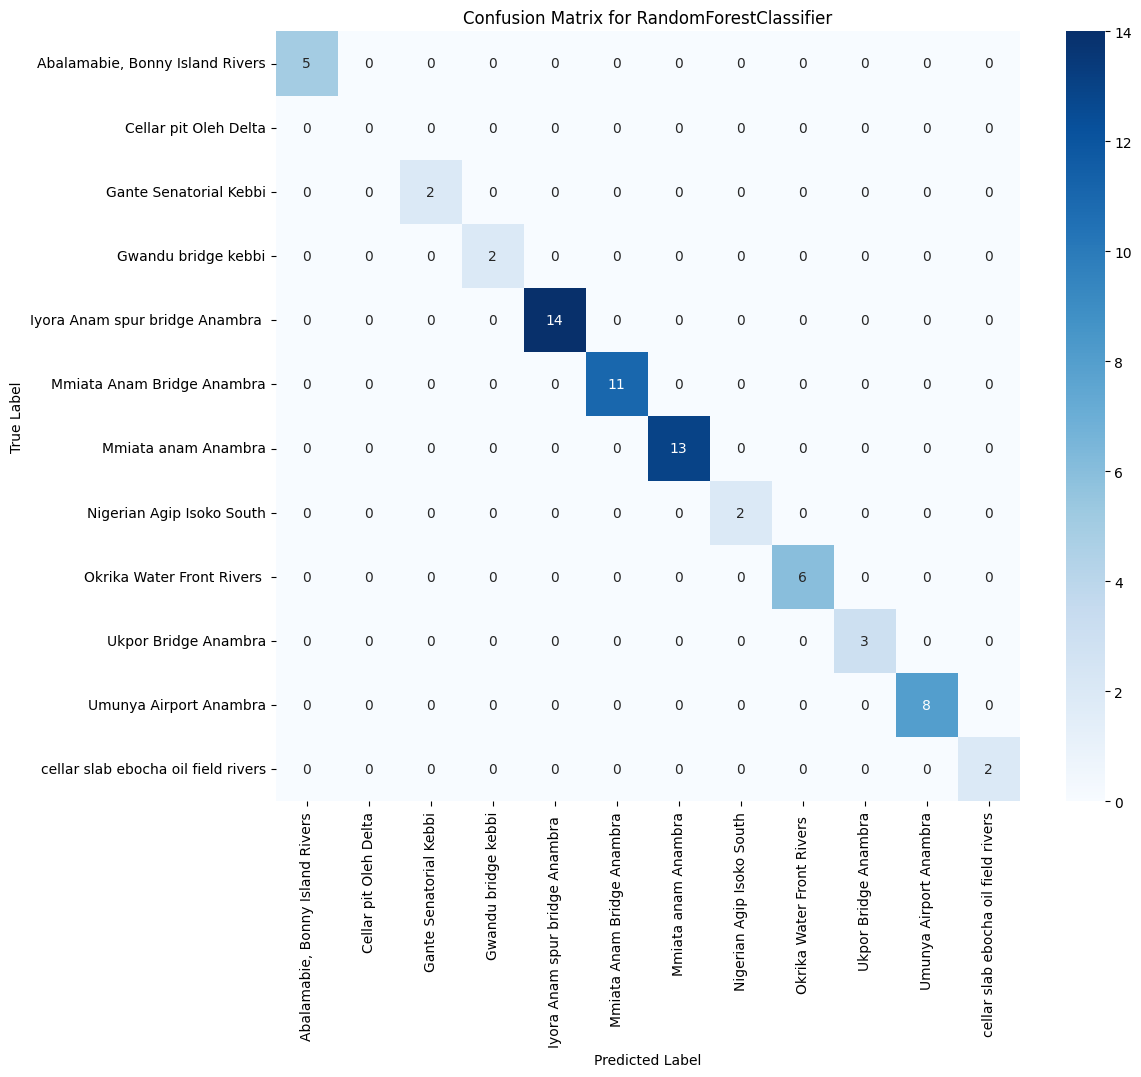


Interpretation for RandomForestClassifier Confusion Matrix:
Each row represents the instances in an actual class, while each column represents the instances in a predicted class.
  - True Positives (TP): Values on the diagonal represent the number of instances correctly predicted for each class.
  - False Positives (FP): Values in a column (excluding the diagonal) indicate instances that were incorrectly predicted as belonging to that class (Type I error).
  - False Negatives (FN): Values in a row (excluding the diagonal) indicate instances of that class that were incorrectly predicted as belonging to another class (Type II error).


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get the best performing model (e.g., RandomForestClassifier)
best_model_name = comparison_df.iloc[0]['Model']
best_model = models[best_model_name]

# Make predictions on the test set using the best model
y_pred_best_model = best_model.predict(X_test_cls)

# Generate the confusion matrix
cm = confusion_matrix(y_test_cls, y_pred_best_model, labels=all_class_labels)

# Create a DataFrame for better visualization with class names
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print(f"\nInterpretation for {best_model_name} Confusion Matrix:")
print("Each row represents the instances in an actual class, while each column represents the instances in a predicted class.")
print("  - True Positives (TP): Values on the diagonal represent the number of instances correctly predicted for each class.")
print("  - False Positives (FP): Values in a column (excluding the diagonal) indicate instances that were incorrectly predicted as belonging to that class (Type I error).")
print("  - False Negatives (FN): Values in a row (excluding the diagonal) indicate instances of that class that were incorrectly predicted as belonging to another class (Type II error).")


--- Generating Confusion Matrix for SVC ---


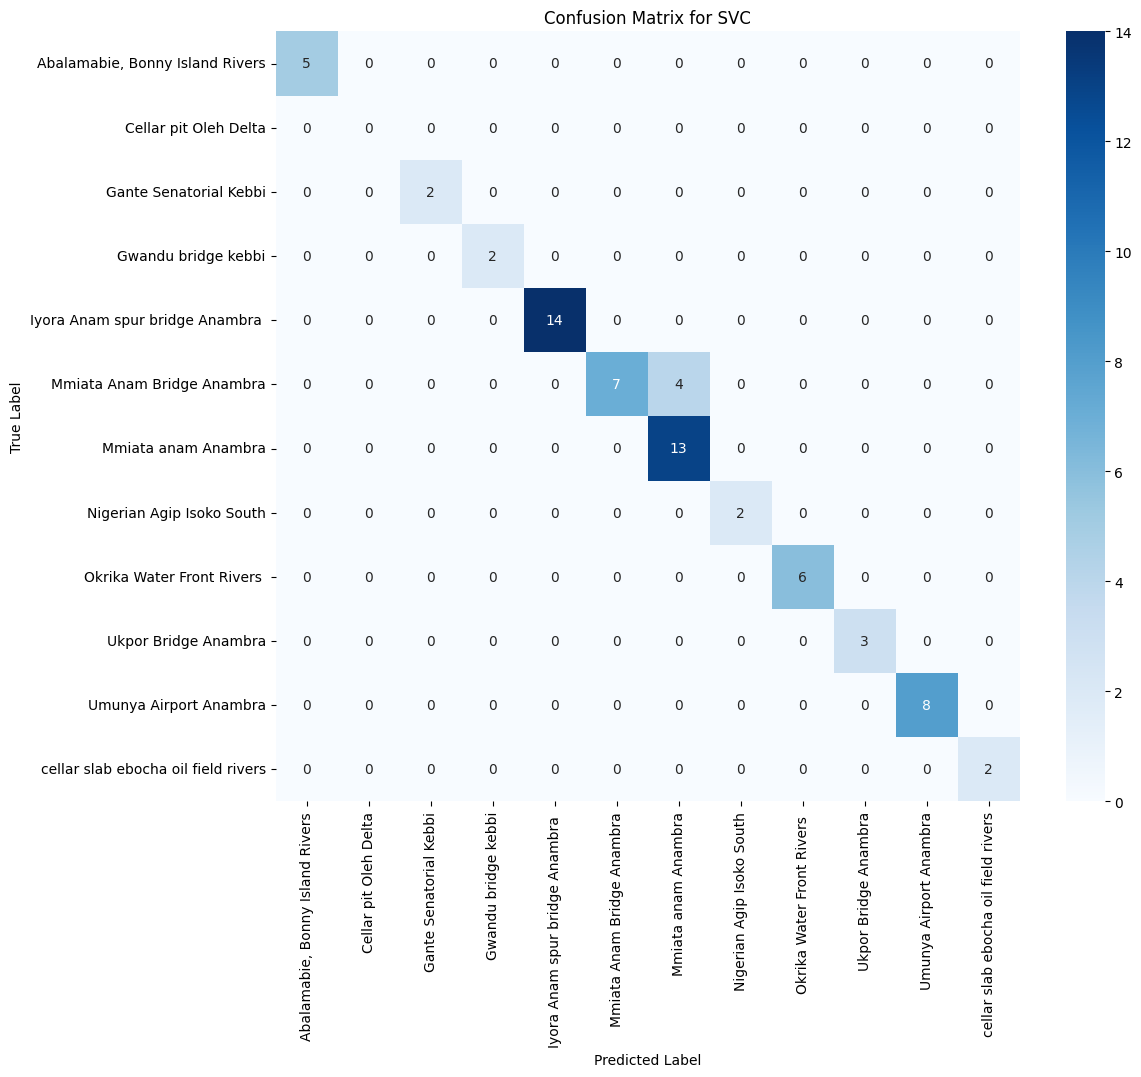


Interpretation for SVC Confusion Matrix:
Each row represents the instances in an actual class, while each column represents the instances in a predicted class.
  - True Positives (TP): Values on the diagonal represent the number of instances correctly predicted for each class.
  - False Positives (FP): Values in a column (excluding the diagonal) indicate instances that were incorrectly predicted as belonging to that class (Type I error).
  - False Negatives (FN): Values in a row (excluding the diagonal) indicate instances of that class that were incorrectly predicted as belonging to another class (Type II error).

--- Generating Confusion Matrix for KNeighborsClassifier ---


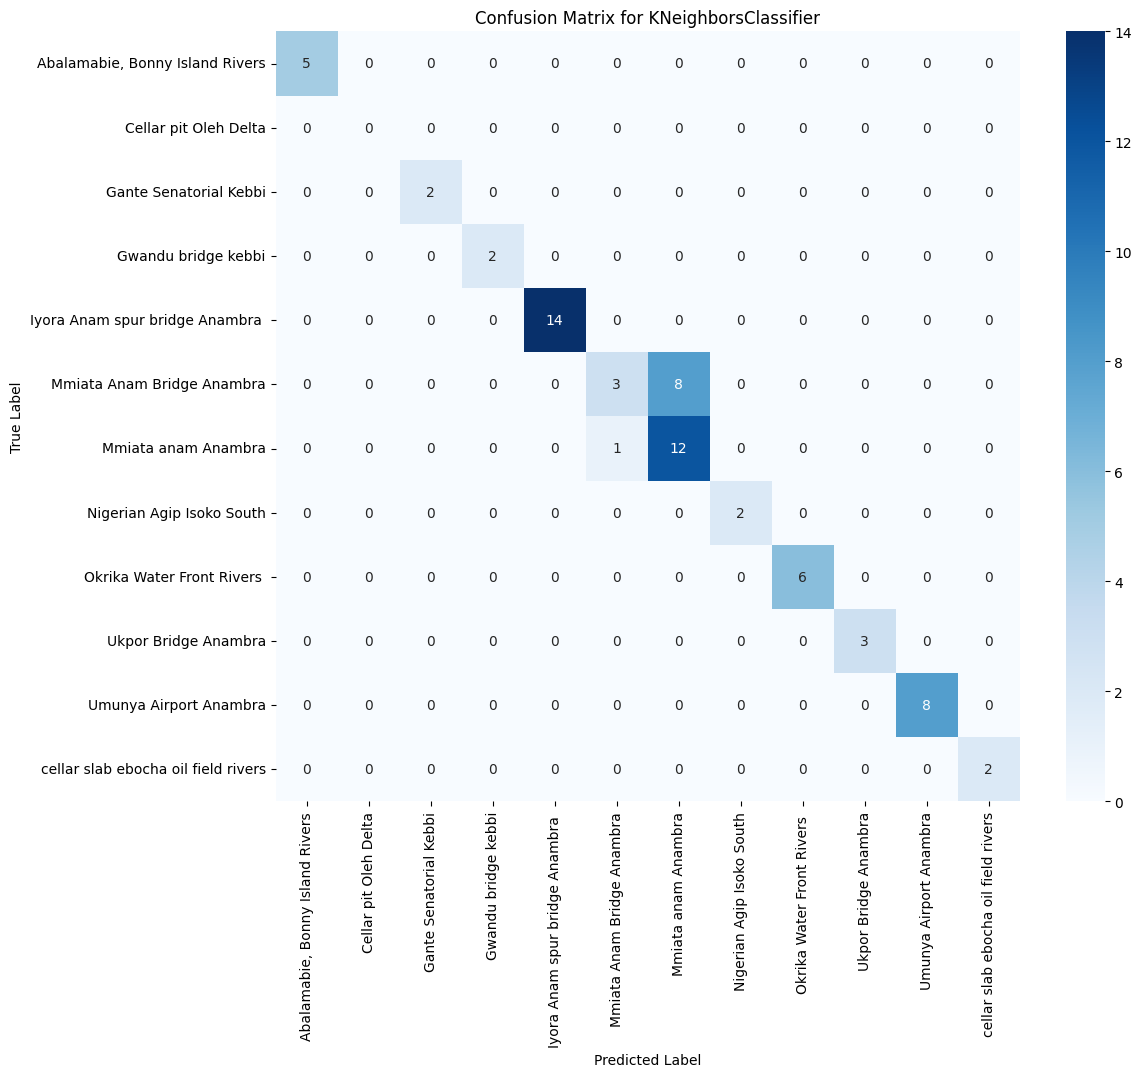


Interpretation for KNeighborsClassifier Confusion Matrix:
Each row represents the instances in an actual class, while each column represents the instances in a predicted class.
  - True Positives (TP): Values on the diagonal represent the number of instances correctly predicted for each class.
  - False Positives (FP): Values in a column (excluding the diagonal) indicate instances that were incorrectly predicted as belonging to that class (Type I error).
  - False Negatives (FN): Values in a row (excluding the diagonal) indicate instances of that class that were incorrectly predicted as belonging to another class (Type II error).


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd # Ensure pandas is imported

# List of models to visualize (excluding those with 100% accuracy for more insightful plots)
models_to_visualize = {
    "SVC": models["SVC"],
    "KNeighborsClassifier": models["KNeighborsClassifier"]
}

for name, model in models_to_visualize.items():
    print(f"\n--- Generating Confusion Matrix for {name} ---")

    # Make predictions on the test set
    y_pred = model.predict(X_test_cls)

    # Generate the confusion matrix
    cm = confusion_matrix(y_test_cls, y_pred, labels=all_class_labels)

    # Create a DataFrame for better visualization with class names
    cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True)
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    print(f"\nInterpretation for {name} Confusion Matrix:")
    print("Each row represents the instances in an actual class, while each column represents the instances in a predicted class.")
    print("  - True Positives (TP): Values on the diagonal represent the number of instances correctly predicted for each class.")
    print("  - False Positives (FP): Values in a column (excluding the diagonal) indicate instances that were incorrectly predicted as belonging to that class (Type I error).")
    print("  - False Negatives (FN): Values in a row (excluding the diagonal) indicate instances of that class that were incorrectly predicted as belonging to another class (Type II error).")


Saving all Classification Learner Algorithms plots to the 'Classification_Plots' directory...


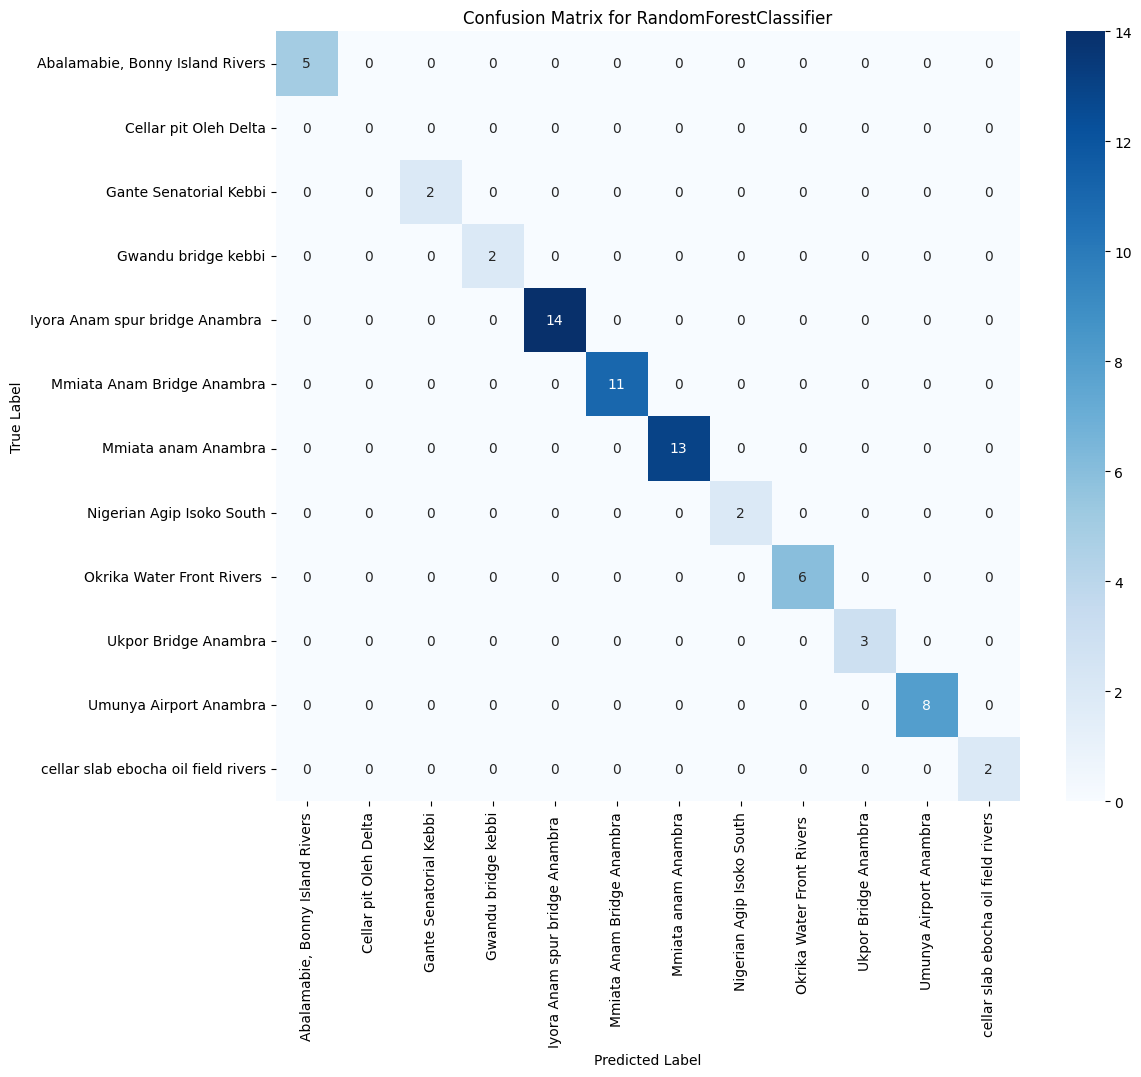

Confusion Matrix for RandomForestClassifier saved.

Generating and saving Confusion Matrix for SVC...


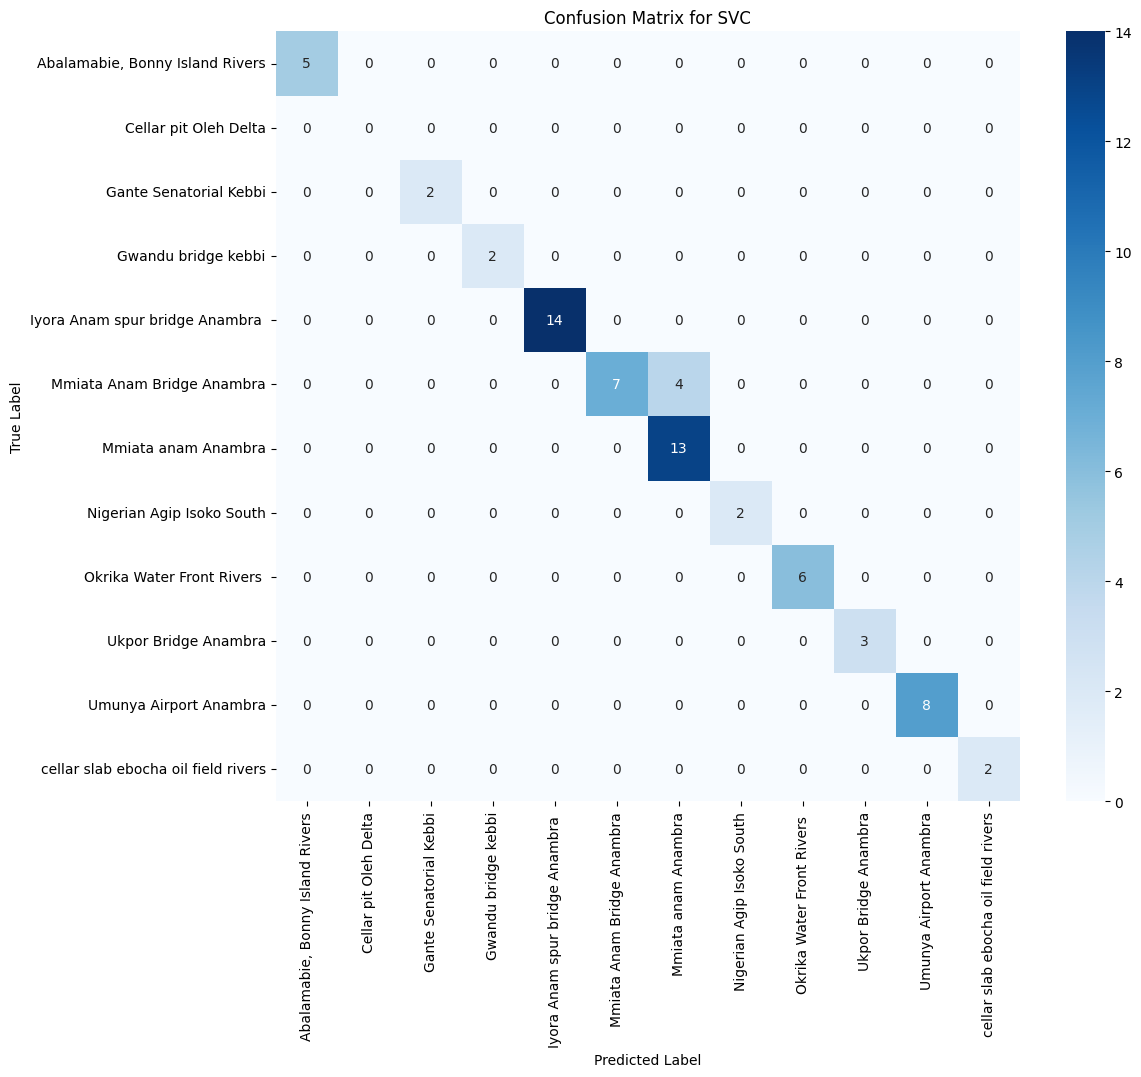

Confusion Matrix for SVC saved.

Generating and saving Confusion Matrix for KNeighborsClassifier...


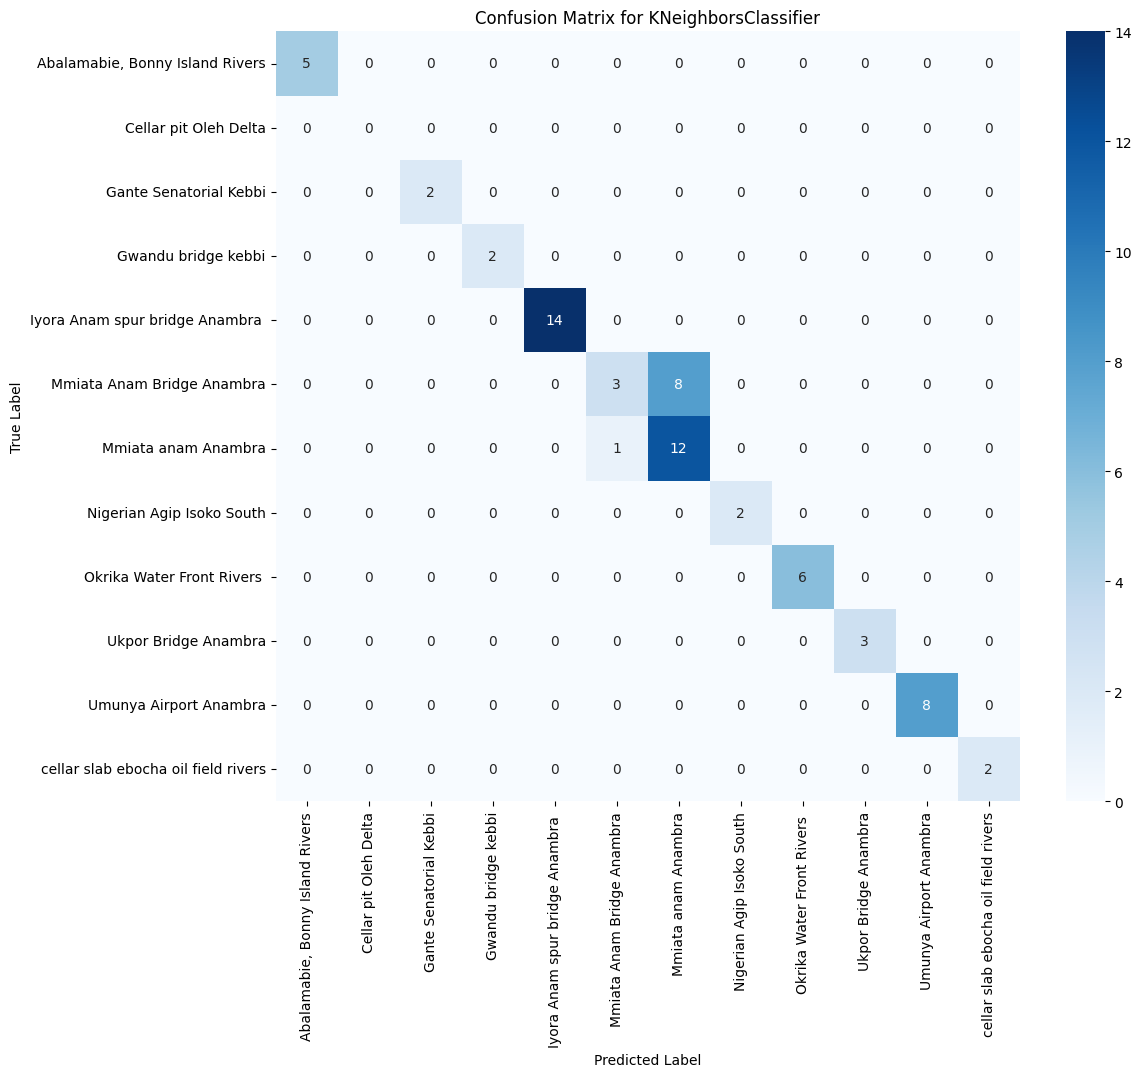

Confusion Matrix for KNeighborsClassifier saved.

All Classification Learner Algorithms plots have been successfully saved to the 'Classification_Plots' directory.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
from sklearn.metrics import confusion_matrix

# Create a directory to save the plots if it doesn't exist
output_folder_cls = 'Classification_Plots'
os.makedirs(output_folder_cls, exist_ok=True)

print(f"Saving all Classification Learner Algorithms plots to the '{output_folder_cls}' directory...")

# --- Plot 1: Confusion Matrix for the Best Performing Model (RandomForestClassifier) ---
# Get the best performing model (e.g., RandomForestClassifier) - assuming comparison_df is available
# from previous execution and best_model_name is set

# Ensure models and related variables are available
if 'models' not in locals():
    print("Error: 'models' dictionary not found. Please ensure classification models were trained.")
elif 'best_model_name' not in locals():
    print("Error: 'best_model_name' not found. Please ensure classification model comparison was run.")
elif 'X_test_cls' not in locals() or 'y_test_cls' not in locals() or 'le' not in locals() or 'all_class_labels' not in locals():
    print("Error: Classification test data or label encoder not found.")
else:
    best_model = models[best_model_name]
    y_pred_best_model = best_model.predict(X_test_cls)

    cm_best = confusion_matrix(y_test_cls, y_pred_best_model, labels=all_class_labels)
    cm_df_best = pd.DataFrame(cm_best, index=le.classes_, columns=le.classes_)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_df_best, annot=True, fmt='d', cmap='Blues', cbar=True)
    plt.title(f'Confusion Matrix for {best_model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig(os.path.join(output_folder_cls, f'confusion_matrix_{best_model_name}.png'))
    plt.show()
    print(f"Confusion Matrix for {best_model_name} saved.")

# --- Plot 2 & 3: Confusion Matrices for SVC and KNeighborsClassifier ---
# models_to_visualize was previously defined to include SVC and KNeighborsClassifier
models_to_visualize_export = {
    "SVC": models["SVC"],
    "KNeighborsClassifier": models["KNeighborsClassifier"]
}

for name, model in models_to_visualize_export.items():
    print(f"\nGenerating and saving Confusion Matrix for {name}...")
    y_pred = model.predict(X_test_cls)
    cm = confusion_matrix(y_test_cls, y_pred, labels=all_class_labels)
    cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True)
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig(os.path.join(output_folder_cls, f'confusion_matrix_{name}.png'))
    plt.show()
    print(f"Confusion Matrix for {name} saved.")

print(f"\nAll Classification Learner Algorithms plots have been successfully saved to the '{output_folder_cls}' directory.")

### Training and Comparing Multiple Regression Models

Now, we will train five different regression models, evaluate their performance using common regression metrics (MAE, MSE, R-squared), and then compare their results.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dictionary to store regression models and their performance
regression_models = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(),
    "GradientBoostingRegressor": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "KNeighborsRegressor": KNeighborsRegressor()
}

regression_performance_metrics = {}

for name, model in regression_models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_reg, y_train_reg)
    y_pred_reg = model.predict(X_test_reg)

    mae = mean_absolute_error(y_test_reg, y_pred_reg)
    mse = mean_squared_error(y_test_reg, y_pred_reg)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_reg, y_pred_reg)

    regression_performance_metrics[name] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

    print(f"{name} MAE: {mae:.4f}")
    print(f"{name} MSE: {mse:.4f}")
    print(f"{name} RMSE: {rmse:.4f}")
    print(f"{name} R2: {r2:.4f}")


--- Training LinearRegression ---
LinearRegression MAE: 198.9038
LinearRegression MSE: 85137.5849
LinearRegression RMSE: 291.7835
LinearRegression R2: 0.9968

--- Training RandomForestRegressor ---
RandomForestRegressor MAE: 265.6515
RandomForestRegressor MSE: 247810.8392
RandomForestRegressor RMSE: 497.8060
RandomForestRegressor R2: 0.9907

--- Training SVR ---
SVR MAE: 4370.8206
SVR MSE: 36104412.4940
SVR RMSE: 6008.6947
SVR R2: -0.3615

--- Training GradientBoostingRegressor ---
GradientBoostingRegressor MAE: 185.5403
GradientBoostingRegressor MSE: 85014.7360
GradientBoostingRegressor RMSE: 291.5729
GradientBoostingRegressor R2: 0.9968

--- Training KNeighborsRegressor ---
KNeighborsRegressor MAE: 550.5691
KNeighborsRegressor MSE: 679255.2734
KNeighborsRegressor RMSE: 824.1694
KNeighborsRegressor R2: 0.9744


Saving all Regression Learner Algorithms plots to the 'Regression_Plots' directory...

Generating Actual vs. Predicted plot for LinearRegression...


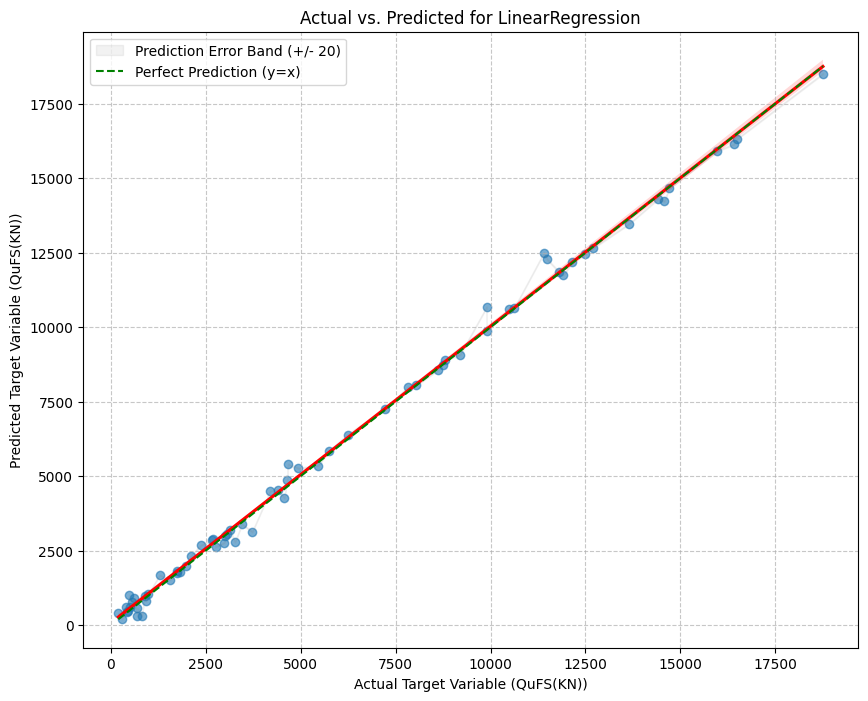

Plot for LinearRegression saved to Regression_Plots/actual_vs_predicted_LinearRegression_with_error_band_v2.png

Generating Actual vs. Predicted plot for RandomForestRegressor...


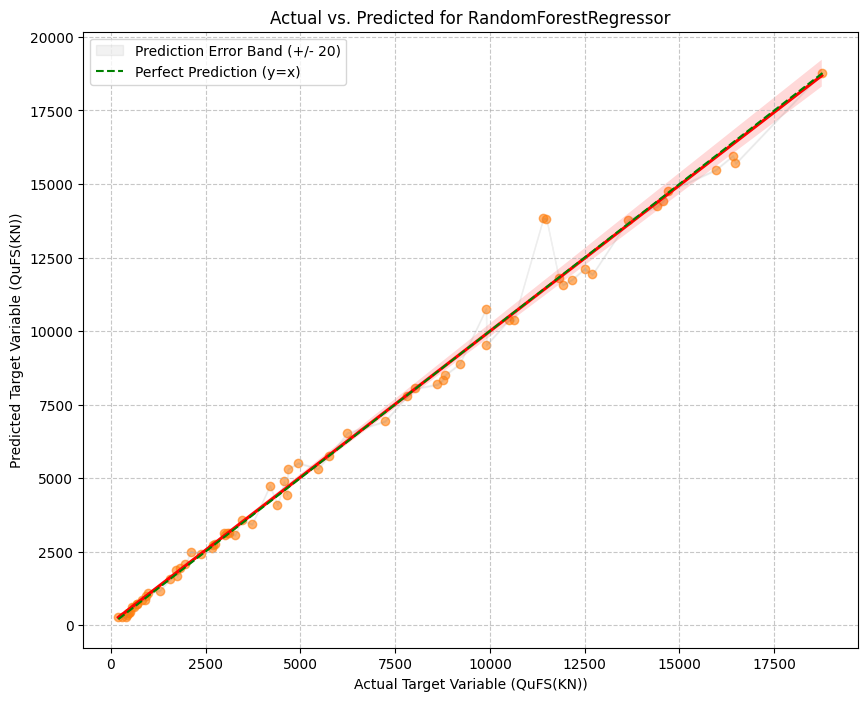

Plot for RandomForestRegressor saved to Regression_Plots/actual_vs_predicted_RandomForestRegressor_with_error_band_v2.png

Generating Actual vs. Predicted plot for SVR...


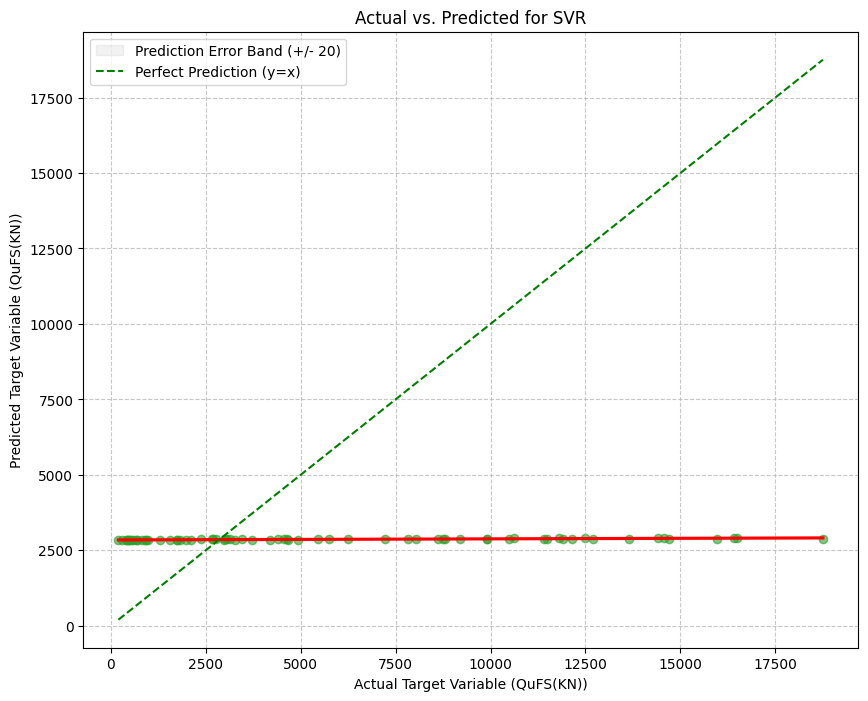

Plot for SVR saved to Regression_Plots/actual_vs_predicted_SVR_with_error_band_v2.png

Generating Actual vs. Predicted plot for GradientBoostingRegressor...


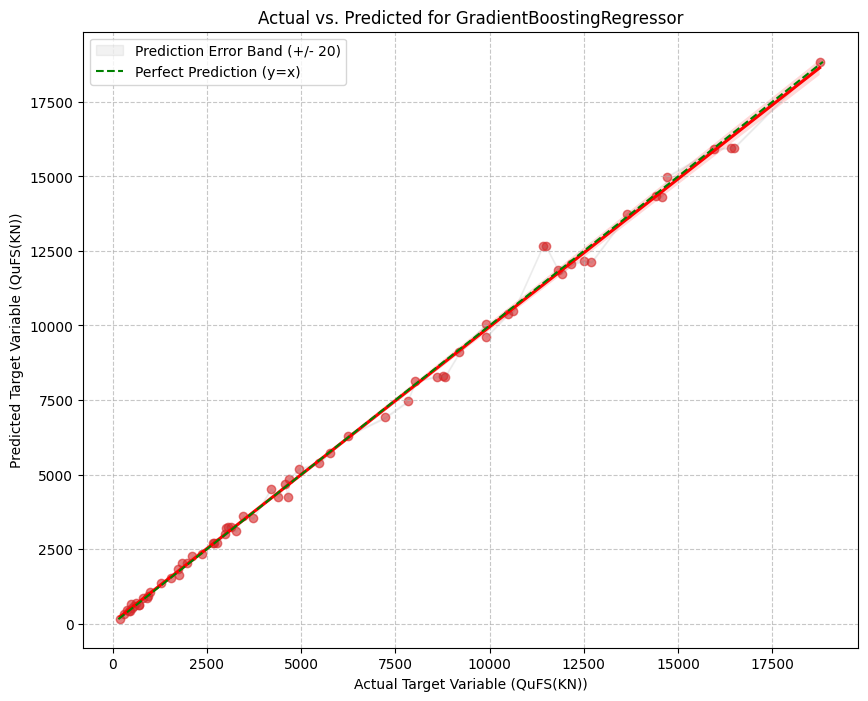

Plot for GradientBoostingRegressor saved to Regression_Plots/actual_vs_predicted_GradientBoostingRegressor_with_error_band_v2.png

Generating Actual vs. Predicted plot for KNeighborsRegressor...


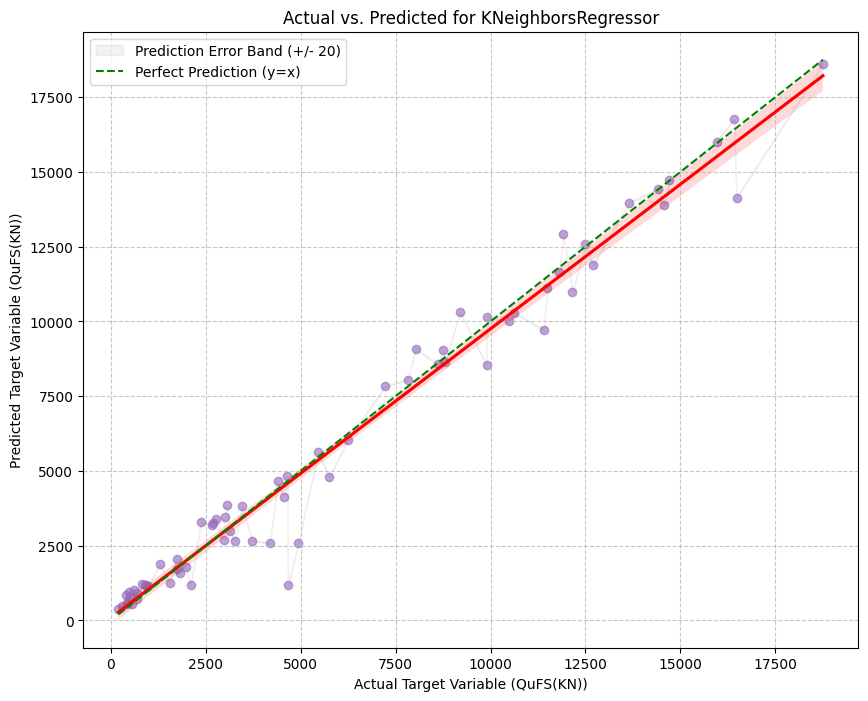

Plot for KNeighborsRegressor saved to Regression_Plots/actual_vs_predicted_KNeighborsRegressor_with_error_band_v2.png

All Regression Learner Algorithms plots have been successfully saved to the 'Regression_Plots' directory.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import pandas as pd

# Create a directory to save the plots if it doesn't exist
output_folder_reg = 'Regression_Plots'
os.makedirs(output_folder_reg, exist_ok=True)

print(f"Saving all Regression Learner Algorithms plots to the '{output_folder_reg}' directory...")

# Define a color palette for the scatter points for each model
palette = sns.color_palette('tab10', len(regression_models)) # 'tab10' has 10 distinct colors
color_iterator = iter(palette)

# Iterate through each trained regression model
for name, model in regression_models.items():
    print(f"\nGenerating Actual vs. Predicted plot for {name}...")

    # Make predictions on the test set
    y_pred_reg = model.predict(X_test_reg)

    # Create a DataFrame for plotting
    plot_df = pd.DataFrame({
        'Actual': y_test_reg,
        'Predicted': y_pred_reg
    })

    plt.figure(figsize=(10, 8))

    # Get a unique color for the scatter points for the current model
    scatter_color = next(color_iterator)

    # Plot the regression line with its default confidence interval
    # Use the unique color for the scatter points and increased alpha
    sns.regplot(x='Actual', y='Predicted', data=plot_df,
                scatter_kws={'alpha':0.6, 'color': scatter_color},
                line_kws={'color':'red'})

    # Add the custom error bands (+/- 20)
    # Calculate upper and lower bounds for the error band
    upper_bound = y_pred_reg + 20
    lower_bound = y_pred_reg - 20

    # Sort by actual values to ensure correct plotting of fill_between
    # Convert y_test_reg to numpy array for consistent indexing
    actual_values = y_test_reg.values if isinstance(y_test_reg, pd.Series) else y_test_reg
    sorted_indices = np.argsort(actual_values)

    plt.fill_between(actual_values[sorted_indices], lower_bound[sorted_indices], upper_bound[sorted_indices],
                     color='grey', alpha=0.1, label='Prediction Error Band (+/- 20)')

    # Add a perfect prediction line (y=x)
    min_val = min(y_test_reg.min(), y_pred_reg.min())
    max_val = max(y_test_reg.max(), y_pred_reg.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='green', linestyle='--', label='Perfect Prediction (y=x)')

    plt.title(f'Actual vs. Predicted for {name}')
    plt.xlabel('Actual Target Variable (QuFS(KN))')
    plt.ylabel('Predicted Target Variable (QuFS(KN))')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plot_filename = os.path.join(output_folder_reg, f'actual_vs_predicted_{name}_with_error_band_v2.png')
    plt.savefig(plot_filename)
    plt.show()
    print(f"Plot for {name} saved to {plot_filename}")

print(f"\nAll Regression Learner Algorithms plots have been successfully saved to the '{output_folder_reg}' directory.")

### Model Comparison (Regression)

Let's compare the performance of all trained regression models.

In [ ]:
import pandas as pd

comparison_df_reg = pd.DataFrame(columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2'])

for name, metrics in regression_performance_metrics.items():
    comparison_df_reg.loc[len(comparison_df_reg)] = [
        name, metrics['MAE'], metrics['MSE'], metrics['RMSE'], metrics['R2']
    ]

comparison_df_reg = comparison_df_reg.sort_values(by='R2', ascending=False).reset_index(drop=True)

print("\n--- Regression Model Comparison ---")
display(comparison_df_reg)


--- Regression Model Comparison ---


,Model,MAE,MSE,RMSE,R2
0,GradientBoostingRegressor,185.540326,8.501474e+04,291.572866,0.996794
1,LinearRegression,198.903763,8.513758e+04,291.783455,0.996789
2,RandomForestRegressor,265.651471,2.478108e+05,497.806026,0.990655
3,KNeighborsRegressor,550.569118,6.792553e+05,824.169445,0.974384
4,SVR,4370.820588,3.610441e+07,6008.694741,-0.361550


Saving performance plots to the 'Performance_Plots' directory...


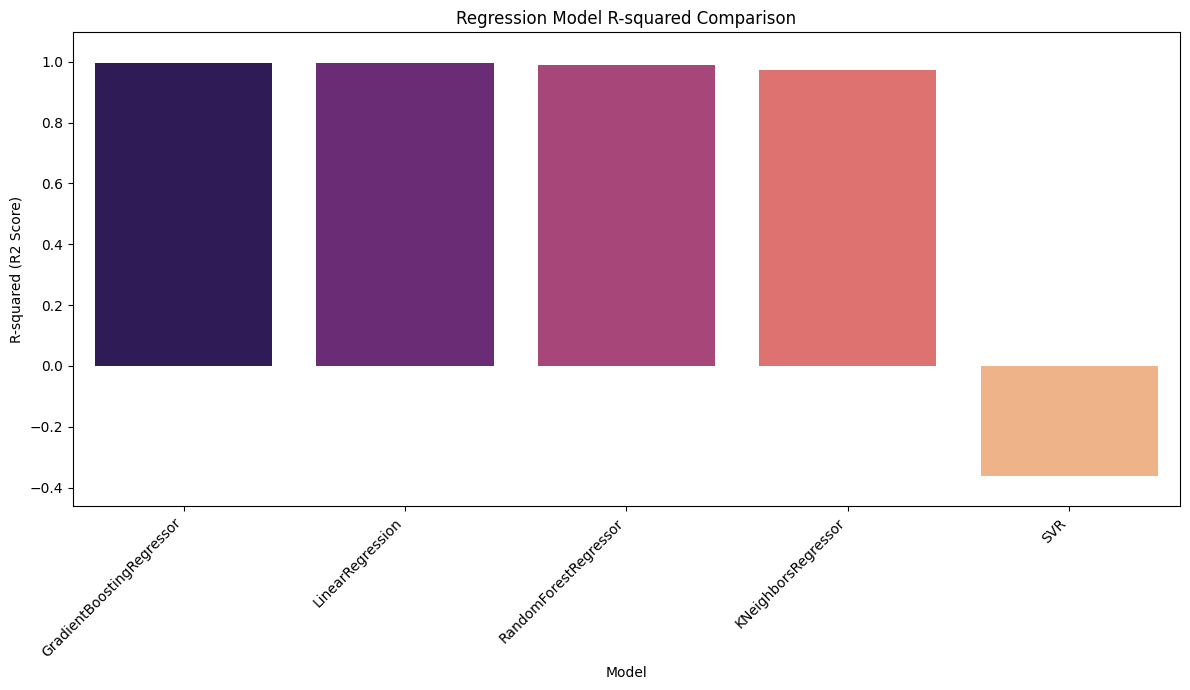

Regression R-squared Bar Chart saved to Performance_Plots/regression_r2_barchart.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create a directory to save performance plots if it doesn't exist
output_folder_perf = 'Performance_Plots'
os.makedirs(output_folder_perf, exist_ok=True)
print(f"Saving performance plots to the '{output_folder_perf}' directory...")

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='R2', data=comparison_df_reg, palette='magma', hue='Model', legend=False)
plt.title('Regression Model R-squared Comparison')
plt.xlabel('Model')
plt.ylabel('R-squared (R2 Score)')

# Adjust y-limit to better visualize differences, especially if R2 can be negative
min_r2 = comparison_df_reg['R2'].min()
max_r2 = comparison_df_reg['R2'].max()
plt.ylim(min_r2 - 0.1, max_r2 + 0.1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plot_filename = os.path.join(output_folder_perf, 'regression_r2_barchart.png')
plt.savefig(plot_filename)
plt.show()
print(f"Regression R-squared Bar Chart saved to {plot_filename}")


In [ ]:
print("\n--- Regression Model Performance Summary ---")
display(comparison_df_reg)


--- Regression Model Performance Summary ---


,Model,MAE,MSE,RMSE,R2
0,GradientBoostingRegressor,185.540326,8.501474e+04,291.572866,0.996794
1,LinearRegression,198.903763,8.513758e+04,291.783455,0.996789
2,RandomForestRegressor,265.651471,2.478108e+05,497.806026,0.990655
3,KNeighborsRegressor,550.569118,6.792553e+05,824.169445,0.974384
4,SVR,4370.820588,3.610441e+07,6008.694741,-0.361550
